# Processo completo de análise e correção de itens - Competição 2: Qualidade de questões geradas com IA generativa -  IV Workshop de Aplicações Práticas de Learning Analytics em Instituições de Ensino no Brasil (WAPLA 2026)

## Objetivo do notebook

Este notebook apresenta, de forma integrada, o processo de análise, seleção e correção dos itens do banco da competição 2 do WAPLA 2026 rejeitados em uma avaliação anterior. A análise parte de um conjunto de 239 itens e combina verificações baseadas em regras com avaliações realizadas por modelo de linguagem.

O processo contempla a caracterização da base, a aplicação dos critérios de diagnóstico, a priorização dos itens com potencial de refino, a correção iterativa e a avaliação dos resultados obtidos. Essa organização permite acompanhar as evidências consideradas em cada etapa e a relação entre o diagnóstico inicial, as decisões de seleção e os resultados das correções.

## Visão geral dos três eixos de diagnóstico

Os 19 critérios do projeto são organizados em três eixos complementares:

| Eixo | Pergunta orientadora | Escopo |
|---|---|---|
| **FE - Formulação e Estrutura** | O item foi construído com clareza, consistência e sem pistas indevidas? | 16 critérios sobre enunciado, gabarito, alternativas, distratores e texto-base. |
| **AP - Alinhamento Pedagógico** | A tarefa solicitada corresponde ao nível cognitivo e ao tipo de questão declarados? | 2 critérios: Taxonomia de Bloom e compatibilidade do formato. |
| **APL - Aplicação** | O item contribui para um conjunto equilibrado de questões? | 1 critério acionável por item: concentração da letra do gabarito no conjunto. |

## Sumário

- [Parte 1 - Exploração inicial dos itens rejeitados](#parte1)
- [Parte 2 - Diagnóstico pelos critérios FE, AP e APL](#parte2)
- [Parte 3 - Seleção dos itens para refino](#parte3)
- [Parte 4 - Demonstração dos componentes do pipeline](#parte4)
- [Parte 5 - Funcionamento do loop de correção](#parte5)
- [Parte 6 - Análise dos resultados da correção](#parte6)
- [Parte 7 - Síntese final](#parte7)

## Etapas do processo e dados utilizados

A tabela a seguir relaciona cada parte do notebook à sua finalidade, aos dados utilizados
e aos produtos gerados ao longo do pipeline:

`base de itens → diagnóstico → seleção → correção iterativa → análise dos resultados`

| Parte | Finalidade | Dados e produtos relacionados |
|---|---|---|
| **1 - Exploração inicial** | Caracteriza a composição da base antes da aplicação dos critérios, considerando tipos de questão, níveis de Bloom, disciplinas, extensão dos enunciados e distribuição das letras do gabarito. | Utiliza `data/rejected_questions.csv`. |
| **2 - Diagnóstico** | Aplica os 19 critérios dos eixos FE, AP e APL e reúne os resultados das verificações automatizadas e da avaliação realizada pela LLM. | Combina a base com `data/text_base_classification_results.csv` e `data/analises_maritaca.csv`; produz `data/sabia-4-thinking/diagnostico_v2/veredito_por_questao.csv`. |
| **3 - Seleção para refino** | Aplica as regras de elegibilidade e o `score_refino` para priorizar até 100 itens com problemas identificáveis e possibilidade de correção. | Produz `data/sabia-4-thinking/diagnostico_v2/itens_para_refino_top100.csv` e compara a seleção com o arquivo de referência. |
| **4 e 5 - Componentes e ciclo de correção** | Demonstra a articulação entre diagnóstico, avaliação e correção, seguida da reavaliação do item a cada rodada. | Utiliza as funções de `item_diagnostic_agent.py`, `item_quality_analyzer.py`, `item_correction_builder.py` e `loop_correcao_avaliacao.py`. Os históricos são armazenados em `data/sabia-4-thinking/loop_correcao_v2/<question_id>.json`. |
| **6 e 7 - Resultados e síntese** | Compara o diagnóstico inicial com as avaliações posteriores, identifica critérios que permaneceram ou surgiram e resume os desfechos. | Utiliza os históricos dos itens selecionados e gera os arquivos `relatorio_*.csv` em `data/sabia-4-thinking/loop_correcao_v2/`. |

> **Nota metodológica:** as verificações baseadas em regras são reprodutíveis quando o
> código e a base permanecem inalterados. As etapas que utilizam modelo de linguagem podem
> apresentar pequenas variações entre execuções; por isso, seus resultados são registrados
> nos arquivos de avaliação e nos históricos de correção.

In [34]:
import inspect
import json
from collections import Counter
from difflib import SequenceMatcher
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chisquare

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 120)

# Módulos do projeto - as mesmas funções utilizadas pelos scripts do pipeline
import item_diagnostic_agent as diag
import item_quality_analyzer as quality
import item_correction_builder as corr
import loop_correcao_avaliacao as loop

PASTA_DIAGNOSTICO = Path('data/sabia-4-thinking/diagnostico_v2')  # saída das Partes 2-3 (diagnóstico + seleção)
PASTA_CORRECAO = Path('data/sabia-4-thinking/loop_correcao_v2')   # entrada das Partes 4-6 (modelo sabia-4-thinking)
PASTA_DIAGNOSTICO.mkdir(parents=True, exist_ok=True)

CORES_STATUS = {
    'APROVADO': '#27ae60', 'CORRIGIDO': '#2980b9', 'LIMITE_RODADAS_ATINGIDO': '#f39c12',
    'DESCARTADO': '#c0392b', 'ERRO_CORRECAO': '#7f8c8d',
}

df = pd.read_csv(diag.REJECTED_PATH)
df['discipline'] = df['discipline'].map(diag.normalizar_disciplina)
print(f'{len(df)} itens carregados de {diag.REJECTED_PATH}')
print(f'{df["discipline"].nunique()} disciplinas | {df["question_type"].nunique()} tipos de questão')

239 itens carregados de /home/lara/Documentos/IV_WAPLA/data/rejected_questions.csv
22 disciplinas | 4 tipos de questão


<a id="parte1"></a>
## Parte 1 - Exploração inicial dos itens rejeitados

Antes de procurar problemas, precisamos compreender a composição da base. Esta etapa
é **descritiva**: ela não aprova nem reprova itens. Seu objetivo é identificar
características que influenciam a leitura das análises seguintes, como a proporção de
cada tipo de questão, a concentração de disciplinas e possíveis desequilíbrios nas
letras do gabarito.

### 1.1 Visão geral e valores ausentes

**Objetivo.** Conferir o número de registros, os tipos das colunas e a presença de
campos vazios antes de iniciar as análises. Essa verificação evita interpretar como
problema pedagógico algo que, na realidade, é uma falha de preenchimento da base.

As colunas `statement_*` e `assertion_*` são usadas apenas por tipos específicos de
questão. Portanto, valores ausentes nesses campos podem ser esperados, devem ser
interpretados em conjunto com `question_type`.

In [35]:
df.info()
print()
nulos = df.isna().mean().sort_values(ascending=False) * 100
print('% de valores nulos por coluna (colunas com algum nulo):')
print(nulos[nulos > 0].round(1).to_string())


<class 'pandas.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   question_id     239 non-null    int64
 1   discipline      239 non-null    str  
 2   question_type   239 non-null    str  
 3   taxonomy_level  239 non-null    str  
 4   base_text       239 non-null    str  
 5   stem            239 non-null    str  
 6   statement_i     30 non-null     str  
 7   statement_ii    30 non-null     str  
 8   statement_iii   30 non-null     str  
 9   statement_iv    30 non-null     str  
 10  assertion_i     16 non-null     str  
 11  assertion_ii    16 non-null     str  
 12  option_a        239 non-null    str  
 13  option_b        239 non-null    str  
 14  option_c        239 non-null    str  
 15  option_d        239 non-null    str  
 16  option_e        239 non-null    str  
 17  correct_option  239 non-null    str  
dtypes: int64(1), str(17)
memory usage: 33.7 K

### 1.2 Distribuição por tipo de questão

**Objetivo.** Identificar quais formatos predominam na base. Como cada tipo possui
regras estruturais próprias, essa distribuição ajuda a interpretar a frequência das
falhas e permite verificar se os resultados posteriores estão concentrados em um único
formato.

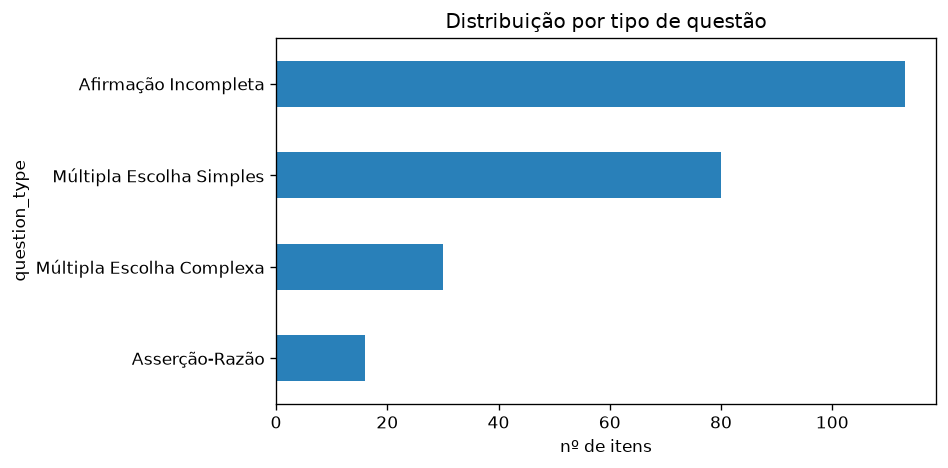

question_type
Afirmação Incompleta         113
Múltipla Escolha Simples      80
Múltipla Escolha Complexa     30
Asserção-Razão                16
Name: count, dtype: int64

In [36]:
tipo_counts = df['question_type'].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
tipo_counts.sort_values().plot(kind='barh', color='#2980b9', ax=ax)
ax.set_xlabel('nº de itens'); ax.set_title('Distribuição por tipo de questão')
plt.tight_layout(); plt.show()
tipo_counts


### 1.3 Distribuição por nível de Bloom declarado

**Objetivo.** Descrever os níveis cognitivos informados nos metadados dos itens. Neste
momento, o nível é apenas o que foi **declarado pelo autor**, seu alinhamento com a
tarefa realmente solicitada será verificado no eixo AP. Uma concentração em determinado
nível não é, por si só, um erro, mas revela o perfil cognitivo da base.

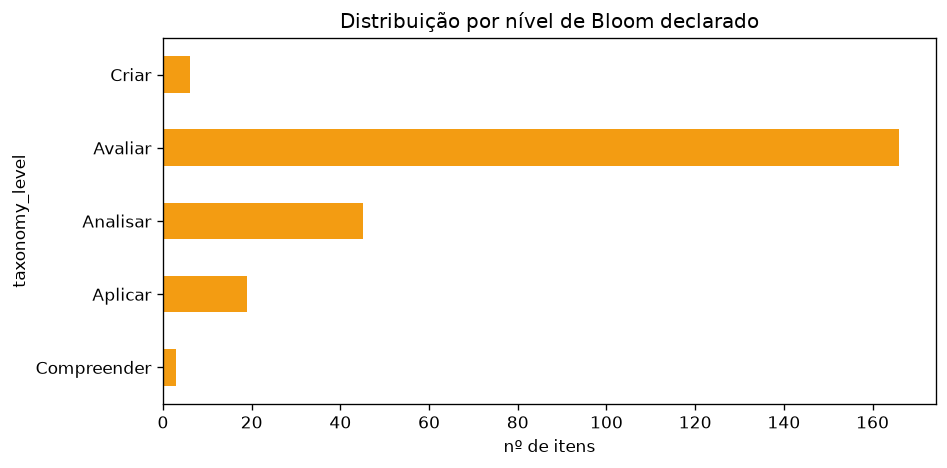

taxonomy_level
Compreender      3
Aplicar         19
Analisar        45
Avaliar        166
Criar            6
Name: count, dtype: int64

In [37]:
BLOOM_ORDER = ['Lembrar', 'Compreender', 'Aplicar', 'Analisar', 'Avaliar', 'Criar']
presentes = [b for b in BLOOM_ORDER if b in df['taxonomy_level'].unique()]
bloom_counts = df['taxonomy_level'].value_counts().reindex(presentes)
fig, ax = plt.subplots(figsize=(8, 4))
bloom_counts.plot(kind='barh', color='#f39c12', ax=ax)
ax.set_xlabel('nº de itens'); ax.set_title('Distribuição por nível de Bloom declarado')
plt.tight_layout(); plt.show()
bloom_counts


### 1.4 Distribuição por disciplina

**Objetivo.** Verificar se poucas disciplinas concentram grande parte dos itens. Essa
informação é relevante porque uma seleção baseada apenas no número de problemas pode
reproduzir a composição desigual da base.

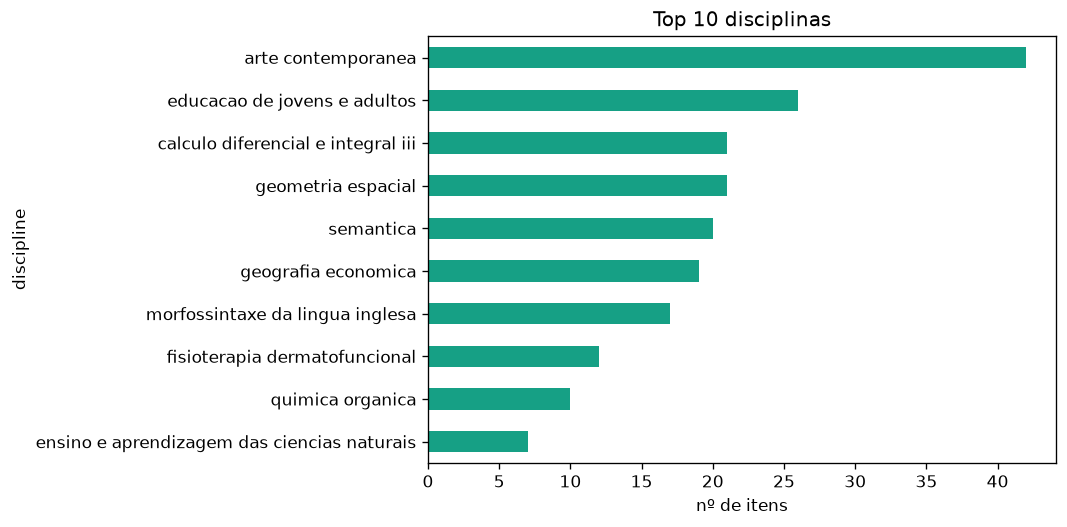

22 disciplinas distintas | top 3 concentram 37.2% dos itens


In [38]:
disc_counts = df['discipline'].value_counts()
fig, ax = plt.subplots(figsize=(9, 4.5))
disc_counts.head(10).sort_values().plot(kind='barh', color='#16a085', ax=ax)
ax.set_xlabel('nº de itens'); ax.set_title('Top 10 disciplinas')
plt.tight_layout(); plt.show()
print(f'{disc_counts.shape[0]} disciplinas distintas | top 3 concentram '
      f'{disc_counts.head(3).sum() / disc_counts.sum() * 100:.1f}% dos itens')


### 1.5 Distribuição do gabarito

**Objetivo.** Avaliar se as alternativas corretas estão distribuídas de forma próxima
ao esperado entre A, B, C, D e E. O teste qui-quadrado compara a distribuição observada
com uma distribuição uniforme de 20% por letra.

Um resultado com `p < 0,05` indica que o desequilíbrio do conjunto dificilmente seria
explicado apenas por variação aleatória. Isso não torna um item individual incorreto;
serve para identificar a letra sobre-representada, usada posteriormente no critério 19
do eixo APL.

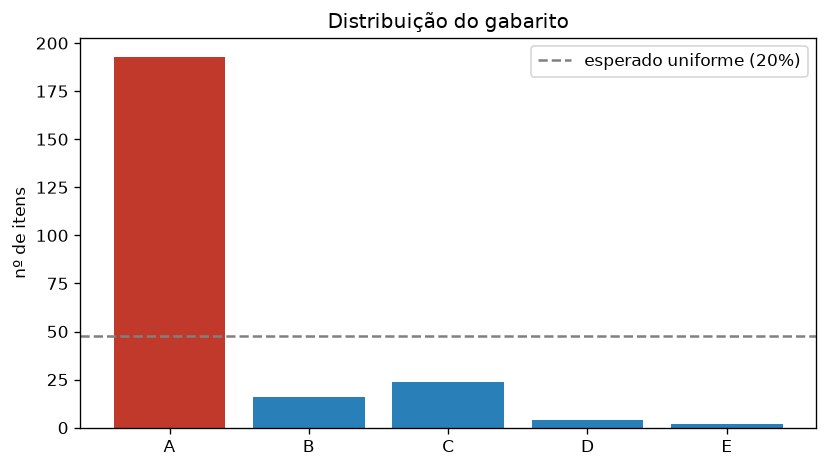

Letra dominante: A | qui-quadrado=558.1 | p=1.82e-119
-> viés estatisticamente significativo (p<0.05)


In [39]:
opcao_counts = df['correct_option'].astype(str).str.upper().value_counts().reindex(['A','B','C','D','E'], fill_value=0)
chi2, p_vies = chisquare(opcao_counts.values, np.full(5, len(df) / 5))
letra_dominante = opcao_counts.idxmax()

fig, ax = plt.subplots(figsize=(7, 4))
cores = ['#c0392b' if l == letra_dominante else '#2980b9' for l in opcao_counts.index]
ax.bar(opcao_counts.index, opcao_counts.values, color=cores)
ax.axhline(len(df) / 5, color='gray', ls='--', label='esperado uniforme (20%)')
ax.set_title('Distribuição do gabarito'); ax.set_ylabel('nº de itens'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Letra dominante: {letra_dominante} | qui-quadrado={chi2:.1f} | p={p_vies:.2e}')
print('->', 'viés estatisticamente significativo (p<0.05)' if p_vies < 0.05 else 'sem viés significativo')


### 1.6 Relação entre tipo de questão e nível de Bloom declarado

**Objetivo.** Observar como os níveis declarados se distribuem dentro de cada formato.
A tabela cruzada ajuda a localizar combinações muito frequentes ou ausentes e oferece
contexto para o diagnóstico.

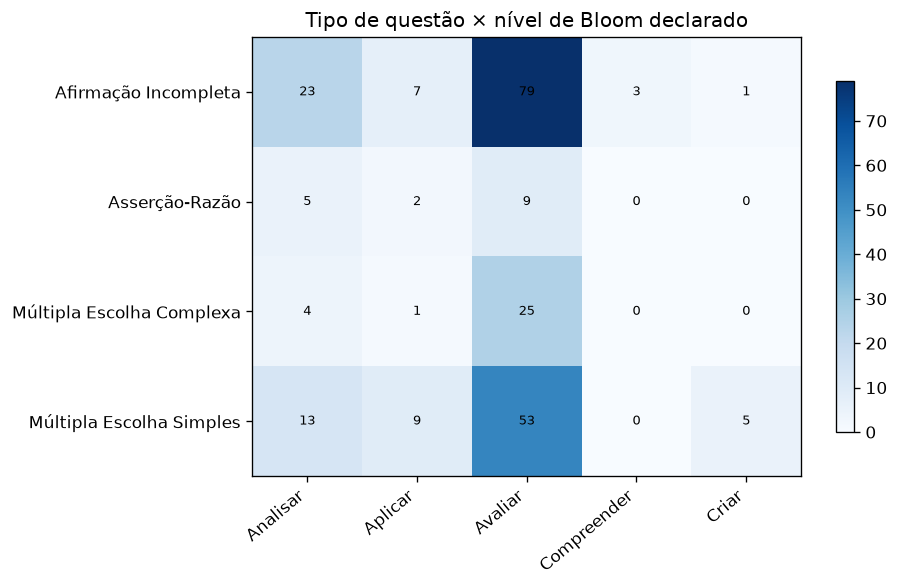

taxonomy_level,Analisar,Aplicar,Avaliar,Compreender,Criar
question_type,,,,,
Afirmação Incompleta,23,7,79,3,1
Asserção-Razão,5,2,9,0,0
Múltipla Escolha Complexa,4,1,25,0,0
Múltipla Escolha Simples,13,9,53,0,5


In [40]:
cross = pd.crosstab(df['question_type'], df['taxonomy_level'])
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(cross.values, cmap='Blues')
ax.set_xticks(range(len(cross.columns))); ax.set_xticklabels(cross.columns, rotation=40, ha='right')
ax.set_yticks(range(len(cross.index))); ax.set_yticklabels(cross.index)
for i in range(len(cross.index)):
    for j in range(len(cross.columns)):
        ax.text(j, i, cross.values[i, j], ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Tipo de questão × nível de Bloom declarado')
plt.tight_layout(); plt.show()
cross


<a id="parte2"></a>
## Parte 2 - Diagnóstico pelos critérios FE, AP e APL

Nesta etapa, a função `item_diagnostic_agent.diagnosticar_dataframe(...)` avalia os 239 itens segundo os 19 critérios dos eixos FE, AP e APL.
Para cada item, são reunidos:

* os resultados das verificações automatizadas baseadas em critérios objetivos;
* a avaliação previamente realizada pela LLM Sabiá-4 e registrada em data/analises_maritaca.csv;
* a classificação sobre a necessidade do texto-base, armazenada em data/text_base_classification_results.csv.

A partir dessas informações, o pipeline identifica as necessidades de melhoria de cada item, contabiliza os problemas por eixo, verifica sua elegibilidade para refino e calcula sua prioridade de seleção.

Ao final, são gerados dois arquivos em `PASTA_DIAGNOSTICO` (atualmente `data/sabia-4-thinking/diagnostico_v2/`):

* veredito_por_questao.csv, com o diagnóstico e a decisão atribuída a cada item;
* itens_para_refino_top100.csv, com os itens selecionados para o processo de correção.

### Como interpretar o diagnóstico

Cada verificação automatizada registra seus resultados por meio de **flags**, que funcionam como alertas internos do sistema. Uma flag recebe o valor `True` quando uma condição que requer revisão é identificada e `False` quando essa condição não está presente. Por exemplo, `fe_alternativas_duplicadas=True` indica que duas ou mais alternativas apresentam o mesmo conteúdo. As flags acionadas permitem registrar os problemas encontrados, relacioná-los aos critérios de diagnóstico e orientar as recomendações de melhoria apresentadas ao corretor.

Os 19 critérios utilizados são:

| Nº | Eixo | O que o critério verifica |
|---:|:---:|---|
| 1 | FE | O gabarito existe e identifica uma única alternativa correta. |
| 2 | FE | Não há alternativas duplicadas ou textualmente equivalentes. |
| 3 | FE | O gabarito não repete o conteúdo de um distrator. |
| 4 | FE | O gabarito é factual ou matematicamente defensável. |
| 5 | FE | As alternativas apresentam extensão e estrutura comparáveis. |
| 6 | FE | A alternativa correta não se destaca pelo tamanho. |
| 7 | FE | Os distratores são plausíveis e evitam formulações obviamente falsas. |
| 8 | FE | Não são usadas opções como “todas” ou “nenhuma das anteriores”. |
| 9 | FE | O enunciado não fornece pistas lexicais exclusivas para o gabarito. |
| 10 | FE | O comando evita formulações negativas desnecessárias. |
| 11 | FE | O que o estudante deve fazer está explicitado no enunciado. |
| 12 | FE | O enunciado não contém lacunas artificiais no meio da frase. |
| 13 | FE | O item não transforma verdadeiro/falso em múltipla escolha de forma disfarçada. |
| 14 | FE | Alternativas numéricas seguem uma ordenação compreensível. |
| 15 | FE | O texto-base é necessário para resolver o item, e não apenas decorativo. |
| 16 | FE | As alternativas permanecem conectadas ao conteúdo solicitado. |
| 17 | AP | A operação cognitiva observada está alinhada ao nível de Bloom declarado. |
| 18 | AP | A estrutura do item é compatível com o tipo de questão declarado. |
| 19 | APL | A letra correta não reforça a alternativa já sobre-representada no conjunto. |

In [41]:
df_diagnosticado = diag.diagnosticar_dataframe(
    caminho_entrada=diag.REJECTED_PATH,
    caminho_textbase_cache=diag.TEXTBASE_CACHE_PATH,   # cache compartilhado, reaproveitado
    caminho_maritaca=diag.MARITACA_PATH,                # cache compartilhado, reaproveitado
    caminho_veredito_saida=PASTA_DIAGNOSTICO / 'veredito_por_questao.csv',
    caminho_refino_saida=PASTA_DIAGNOSTICO / 'itens_para_refino_top100.csv',
    usar_llm_textbase=True,
    mostrar_progresso=True,
)


[diagnostico] 239 itens carregados de /home/lara/Documentos/IV_WAPLA/data/rejected_questions.csv
  [texto-base] 239 em cache | 0 novas a classificar (LLM)
  [25/239] diagnosticados (último: question_id=78, n_melhorias=3)
  [50/239] diagnosticados (último: question_id=160, n_melhorias=2)
  [75/239] diagnosticados (último: question_id=260, n_melhorias=2)
  [100/239] diagnosticados (último: question_id=360, n_melhorias=3)
  [125/239] diagnosticados (último: question_id=438, n_melhorias=3)
  [150/239] diagnosticados (último: question_id=516, n_melhorias=1)
  [175/239] diagnosticados (último: question_id=601, n_melhorias=3)
  [200/239] diagnosticados (último: question_id=707, n_melhorias=4)
  [225/239] diagnosticados (último: question_id=792, n_melhorias=5)
  [239/239] diagnosticados (último: question_id=844, n_melhorias=3)
[diagnostico] decisões:
categoria
REFINAR_SELECIONADO    100
REFINAR                 75
INVESTIGAR              63
DESCARTAR                1
[diagnostico] salvo: data/s

### 2.1 Eixo FE - Formulação e Estrutura

Objetivo. Verificar quais problemas relacionados à Formulação e Estrutura aparecem com maior frequência na base. Para cada flag do eixo ``FE``, o gráfico apresenta o número de itens em que a respectiva condição foi identificada. Como um mesmo item pode acionar mais de uma flag, ele pode ser contabilizado em diferentes barras. Frequências elevadas ajudam a identificar problemas recorrentes e aspectos do processo de elaboração que merecem maior atenção, mas não indicam, isoladamente, a gravidade de cada problema.

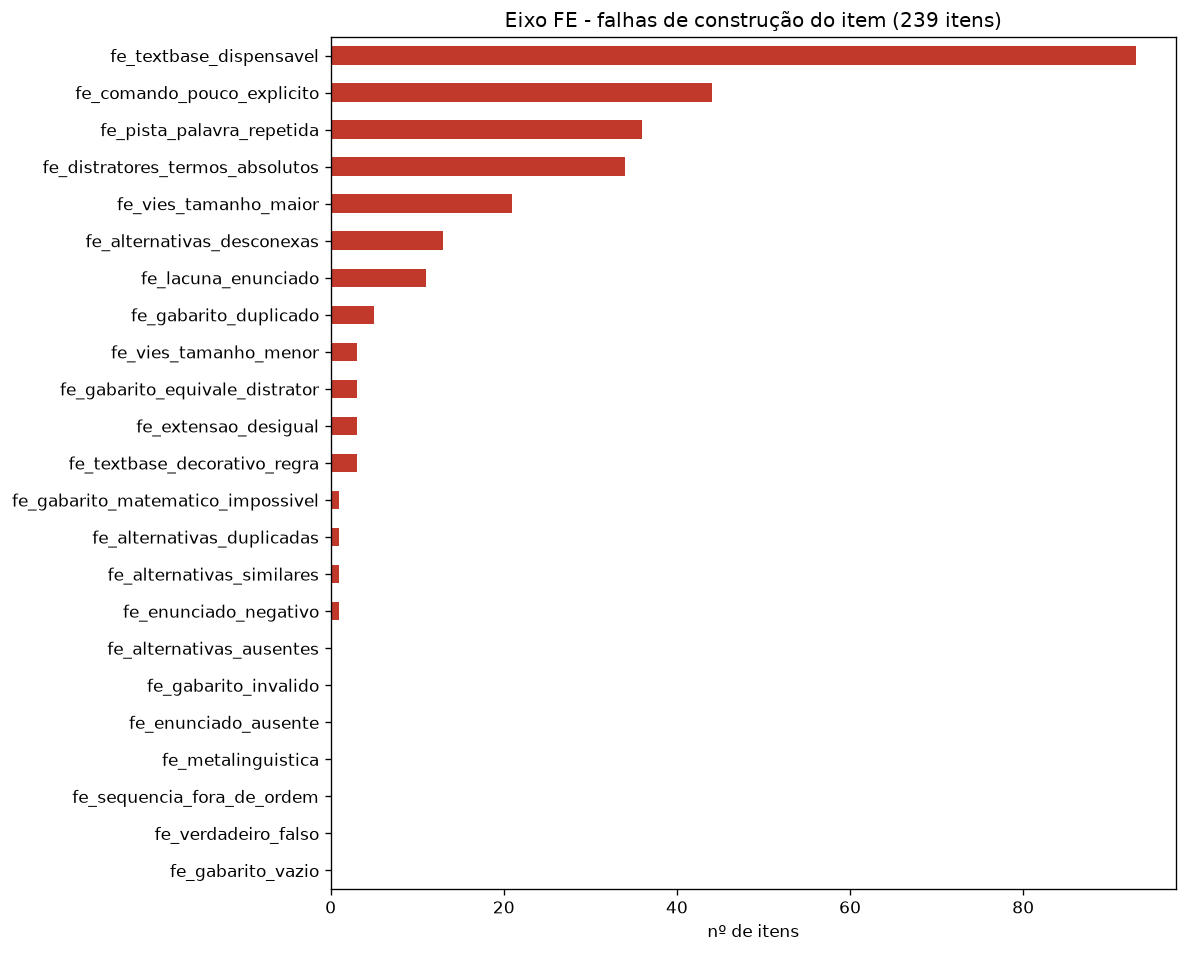

fe_textbase_dispensavel              93
fe_comando_pouco_explicito           44
fe_pista_palavra_repetida            36
fe_distratores_termos_absolutos      34
fe_vies_tamanho_maior                21
fe_alternativas_desconexas           13
fe_lacuna_enunciado                  11
fe_gabarito_duplicado                 5
fe_textbase_decorativo_regra          3
fe_gabarito_equivale_distrator        3
fe_extensao_desigual                  3
fe_vies_tamanho_menor                 3
fe_enunciado_negativo                 1
fe_alternativas_duplicadas            1
fe_alternativas_similares             1
fe_gabarito_matematico_impossivel     1
fe_alternativas_ausentes              0
fe_enunciado_ausente                  0
fe_gabarito_invalido                  0
fe_gabarito_vazio                     0
fe_metalinguistica                    0
fe_sequencia_fora_de_ordem            0
fe_verdadeiro_falso                   0
dtype: int64

In [42]:
cols_fe = sorted([col for col in df_diagnosticado.columns if col.startswith('fe_')])
resumo_fe = df_diagnosticado[cols_fe].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(3, len(resumo_fe) * 0.35)))
resumo_fe.sort_values().plot(kind='barh', color='#c0392b', ax=ax)
ax.set_xlabel('nº de itens'); ax.set_title('Eixo FE - falhas de construção do item (239 itens)')
plt.tight_layout(); plt.show()
resumo_fe


### 2.2 Eixo AP - Alinhamento Bloom e Formato

**Objetivo.** Verificar duas formas de coerência entre a intenção declarada e a tarefa
apresentada ao estudante:

1. `ap_bloom_desalinhado`: o nível inferido a partir do verbo do comando difere do nível
   de Bloom informado no item;
2. `ap_formato_incompativel`: a organização de afirmativas ou asserções não corresponde
   ao `question_type` declarado.

A matriz compara Bloom declarado e detectado. A detecção por verbo é uma heurística e
deve ser lida como alerta para revisão, não como classificação definitiva.

Bloom desalinhado (verbo detectado ≠ declarado): 47 / 239
Formato incompatível com o tipo declarado: 6 / 239


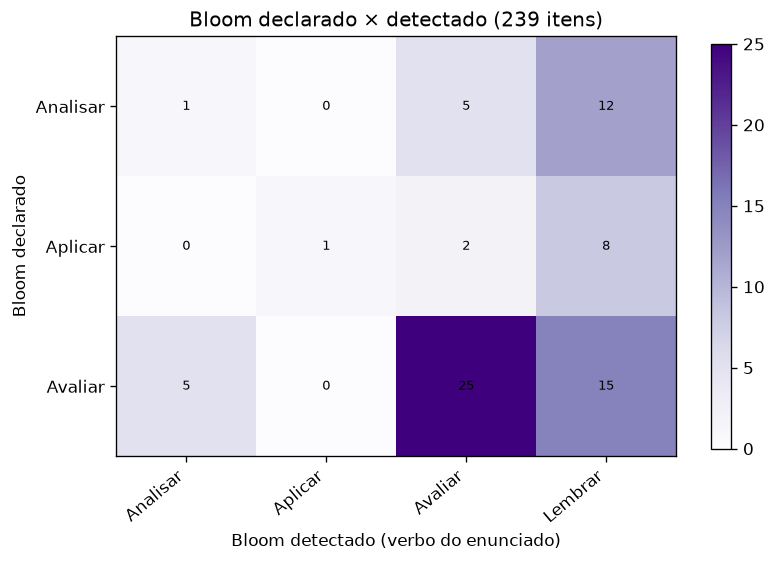

In [43]:
print('Bloom desalinhado (verbo detectado ≠ declarado):',
      int(df_diagnosticado['ap_bloom_desalinhado'].sum()), '/', len(df_diagnosticado))
print('Formato incompatível com o tipo declarado:',
      int(df_diagnosticado['ap_formato_incompativel'].sum()), '/', len(df_diagnosticado))

aval = df_diagnosticado.dropna(subset=['bloom_detectado'])
if len(aval):
    cm = pd.crosstab(aval['taxonomy_level'], aval['bloom_detectado'])
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(cm.values, cmap='Purples')
    ax.set_xticks(range(len(cm.columns))); ax.set_xticklabels(cm.columns, rotation=40, ha='right')
    ax.set_yticks(range(len(cm.index))); ax.set_yticklabels(cm.index)
    ax.set_xlabel('Bloom detectado (verbo do enunciado)'); ax.set_ylabel('Bloom declarado')
    ax.set_title('Bloom declarado × detectado (239 itens)')
    for i in range(len(cm.index)):
        for j in range(len(cm.columns)):
            ax.text(j, i, cm.values[i, j], ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()


> **Nota sobre a avaliação de Bloom:** a matriz acima apresenta somente o resultado da
> verificação automatizada, que identifica o nível de Bloom associado ao verbo do
> enunciado e o compara com o nível declarado.
>
> O diagnóstico também considera a avaliação realizada pela LLM. Nessa avaliação, o item
> é analisado como um todo para determinar a operação cognitiva mínima necessária à sua
> resolução. O nível identificado é registrado em `bloom.nivel_observado`, enquanto
> `bloom.alinhamento` informa se ele está de acordo com o nível declarado (`SIM`, `NAO` ou
> `NAO_AVALIAVEL`). O critério 17 é incluído na lista consolidada de critérios ativos
> quando a verificação automatizada ou a avaliação da LLM identifica desalinhamento.

### 2.3 Panorama dos problemas detectados e decisão preliminar

**Objetivo.** Resumir quantos problemas objetivos foram associados a cada item e como
isso se converte nas categorias usadas para organizar o trabalho de refino. O primeiro
gráfico mostra `n_melhorias`, que reúne sinais dos três eixos; o segundo apresenta a
categoria final atribuída pelo diagnóstico.

As categorias significam:

- `REFINAR_SELECIONADO`: item elegível incluído entre as maiores prioridades;
- `REFINAR`: item elegível, mas fora do limite de itens escolhido para esta rodada;
- `INVESTIGAR`: não há evidência objetiva suficiente para orientar uma correção automática;
- `DESCARTAR`: o item apresenta condição considerada inviável para o refino proposto.

O eixo APL participa dessa contagem por meio do critério 19. A análise estatística que
define a letra dominante foi apresentada na seção 1.5.

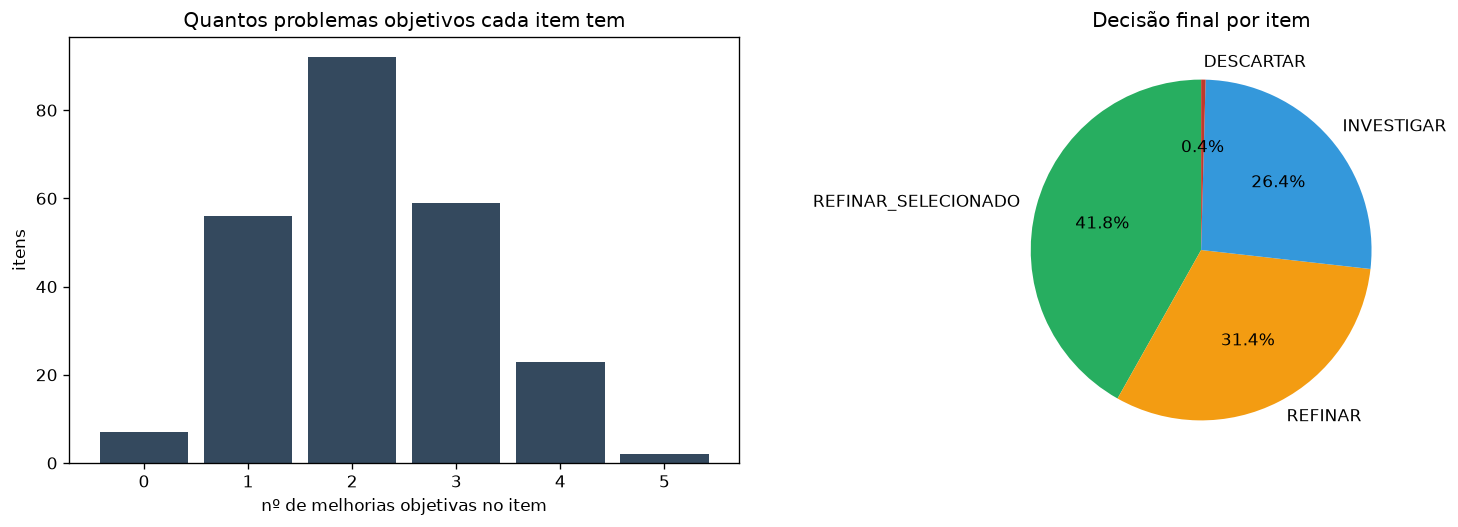

categoria
REFINAR_SELECIONADO    100
REFINAR                 75
INVESTIGAR              63
DESCARTAR                1


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bins = range(0, int(df_diagnosticado['n_melhorias'].max()) + 2)
axes[0].hist(df_diagnosticado['n_melhorias'], bins=bins, color='#34495e', align='left', rwidth=0.85)
axes[0].set_xlabel('nº de melhorias objetivas no item'); axes[0].set_ylabel('itens')
axes[0].set_title('Quantos problemas objetivos cada item tem')

CORES_DECISAO = {'REFINAR_SELECIONADO': '#27ae60', 'REFINAR': '#f39c12',
                  'INVESTIGAR': '#3498db', 'DESCARTAR': '#c0392b'}
cont_decisao = df_diagnosticado['categoria'].value_counts()
axes[1].pie(cont_decisao.values, labels=cont_decisao.index,
            colors=[CORES_DECISAO.get(k, '#888') for k in cont_decisao.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Decisão final por item')
plt.tight_layout(); plt.show()

print(cont_decisao.to_string())


<a id="parte3"></a>
## Parte 3 - Seleção dos itens para refino

O diagnóstico identifica os problemas presentes em cada item, enquanto a etapa de seleção utiliza essas informações para definir quais itens serão encaminhados ao processo de refino. O objetivo não é simplesmente escolher aqueles com maior número de problemas, mas priorizar os itens cujas necessidades de melhoria estão claramente identificadas e podem ser tratadas pelo processo de correção proposto.


In [45]:
selecionados_novos = df_diagnosticado[df_diagnosticado['categoria'] == 'REFINAR_SELECIONADO']
print(f'{len(selecionados_novos)} itens selecionados para refino nesta corrida')
print()
print('Composição por tipo de questão:')
print(selecionados_novos['question_type'].value_counts().to_string())
print()
print('Composição por nível de Bloom:')
print(selecionados_novos['taxonomy_level'].value_counts().to_string())


100 itens selecionados para refino nesta corrida

Composição por tipo de questão:
question_type
Múltipla Escolha Simples     51
Afirmação Incompleta         45
Asserção-Razão                2
Múltipla Escolha Complexa     2

Composição por nível de Bloom:
taxonomy_level
Avaliar     80
Analisar    12
Aplicar      5
Criar        3


### 3.1 Comparação com a seleção anterior

In [46]:
ids_novos = set(selecionados_novos['question_id'])
if diag.REFINO_PATH.exists():
    ids_antigos = set(pd.read_csv(diag.REFINO_PATH, encoding='utf-8-sig')['question_id'])
    iguais = ids_novos & ids_antigos
    print(f'Seleção anterior: {len(ids_antigos)} itens | Seleção desta corrida: {len(ids_novos)} itens')
    print(f'Em comum: {len(iguais)} ({len(iguais)/max(len(ids_antigos),1)*100:.1f}% da seleção anterior)')
    print(f'Só na seleção nova: {sorted(ids_novos - ids_antigos)}')
    print(f'Só na seleção anterior (saíram): {sorted(ids_antigos - ids_novos)}')
else:
    print('Não há seleção anterior em data/itens_para_refino_top100.csv para comparar.')


Seleção anterior: 100 itens | Seleção desta corrida: 100 itens
Em comum: 100 (100.0% da seleção anterior)
Só na seleção nova: []
Só na seleção anterior (saíram): []


<a id="parte4"></a>
## Parte 4 - Demonstração dos componentes do pipeline

Esta seção utiliza um dos itens selecionados para demonstrar o funcionamento integrado do processo de correção. Inicialmente, o item é submetido ao diagnóstico dos critérios FE, AP e APL. Em seguida, a LLM realiza a avaliação e identifica aspectos que exigem revisão. Por fim, os resultados dessas duas etapas são reunidos para orientar a geração de uma versão corrigida do item.

| Componente | Responsabilidade | Saída usada na etapa seguinte |
|---|---|---|
| Diagnóstico automatizado | Executa as verificações objetivas e registra as flags acionadas. | Critérios ativos e necessidades de melhoria. |
| Avaliação por LLM | Analisa o item como um todo, incluindo sua resolução, coerência, clareza e alinhamento de Bloom. | Resultados dos critérios avaliados pela LLM, Bloom observado e decisão recomendada. |
| Correção por LLM | Utiliza os critérios ativos para produzir uma nova versão do item. | Item corrigido e descrição das alterações realizadas. |

O `question_id=2` é utilizado como exemplo ao longo da seção. A apresentação do mesmo
item nas três etapas permite relacionar as flags iniciais, os resultados da avaliação
realizada pela LLM e as alterações produzidas na primeira correção.

> **Modelo de linguagem utilizado.** As chamadas de LLM deste notebook (avaliação e
> correção, `item_quality_analyzer.criar_modelo`) usam a API da Maritaca AI. O modelo é
> definido pela variável de ambiente `MARITACA_MODEL` (padrão `"sabia-4"` quando não
> definida - ver [item_quality_analyzer.py](item_quality_analyzer.py)); os resultados
> analisados neste notebook (`PASTA_CORRECAO`) usam **`sabia-4-thinking`**, a variante com
> raciocínio estendido. A seção 6.8 compara esses resultados com duas corridas feitas com
> `sabia-4` (`data/sabia-4/loop_correcao_v1` e `data/sabia-4/loop_correcao_v2`), geradas do
> mesmo modo mas fora do fluxo padrão deste notebook - por isso aparecem como pastas à
> parte, não como saída de uma célula acima.

### 4.0 Verificação dos históricos de correção

As análises desta seção utilizam os históricos armazenados em
`PASTA_CORRECAO/<question_id>.json`. Esses arquivos registram, para cada rodada, o item
avaliado, as flags identificadas, os critérios ativos, a resposta da LLM, a correção
produzida e o status resultante.

Antes de prosseguir, a célula verifica se todos os itens selecionados possuem um histórico
concluído. Arquivos ausentes, inválidos ou interrompidos são encaminhados a
`executar_lote`, função responsável por executar até três correções e quatro avaliações
por item. Os históricos já concluídos são preservados para evitar novo processamento e
novas chamadas à API.

In [47]:
MAX_WORKERS_CORRECAO = 3  # use 1 (sequencial) se a API estiver instável ou apresentar timeout

ids_selecionados = sorted(int(q) for q in selecionados_novos['question_id'])
faltantes = []
for qid in ids_selecionados:
    caminho_historico = PASTA_CORRECAO / f'{qid}.json'
    try:
        rodadas_existentes = json.loads(caminho_historico.read_text(encoding='utf-8'))
        status_existente = rodadas_existentes[-1].get('status') if rodadas_existentes else None
    except (OSError, json.JSONDecodeError, KeyError, TypeError):
        status_existente = None
    if status_existente not in loop.STATUS_TERMINAIS:
        faltantes.append(qid)

if faltantes:
    print(f'{len(faltantes)} de {len(ids_selecionados)} itens selecionados ainda não têm correção '
          f'concluída em {PASTA_CORRECAO} - iniciando o processamento '
          f'(pode haver chamadas à LLM; max_workers={MAX_WORKERS_CORRECAO})...')
    resumo_execucao = loop.executar_lote(
        faltantes,
        n_iteracoes=3,
        saida_dir=PASTA_CORRECAO,
        reaproveitar_avaliacao_inicial=False,
        max_workers=MAX_WORKERS_CORRECAO,
        pular_concluidos=True,
    )
    print()
    print('Resultado da execução:')
    print(resumo_execucao['status_final'].value_counts().to_string())
else:
    print(f'Todos os {len(ids_selecionados)} itens selecionados possuem histórico concluído '
          f'em {PASTA_CORRECAO}. Nenhuma chamada adicional à LLM foi necessária.')


Todos os 100 itens selecionados possuem histórico concluído em data/sabia-4-thinking/loop_correcao_v2. Nenhuma chamada adicional à LLM foi necessária.


In [48]:
ITEM_EXEMPLO_PREFERENCIAL = 2
ITEM_EXEMPLO = (ITEM_EXEMPLO_PREFERENCIAL if ITEM_EXEMPLO_PREFERENCIAL in ids_selecionados
                else ids_selecionados[0])
item_original = selecionados_novos[selecionados_novos['question_id'] == ITEM_EXEMPLO].iloc[0]
print(f'Item de exemplo: question_id={ITEM_EXEMPLO}')
print(f'Tipo: {item_original["question_type"]} | Disciplina: {item_original["discipline"]}')
print(f'Letra dominante do conjunto (usada no critério 19): {letra_dominante}')
print()
print('Enunciado original:')
print(item_original['stem'])


Item de exemplo: question_id=2
Tipo: Afirmação Incompleta | Disciplina: educacao de jovens e adultos
Letra dominante do conjunto (usada no critério 19): A

Enunciado original:
Nesse contexto, uma ação pedagógica adequada à EJA deve reconhecer que seus estudantes...


### 4.1 Componente 1 - Diagnóstico automatizado

**Objetivo.** Apresentar as verificações objetivas aplicadas diretamente ao item. A função
`item_diagnostic_agent.diagnosticar_item` examina aspectos como validade do gabarito,
similaridade entre alternativas, extensão dos textos, presença de pistas e compatibilidade
do formato. As condições identificadas são registradas por flags e relacionadas aos 19
critérios do diagnóstico. Essa etapa não realiza chamada à LLM.

> No diagnóstico em lote, o critério 15 utiliza preferencialmente a classificação da
> necessidade do texto-base armazenada em cache. Na demonstração de um item isolado, quando
> essa classificação não é fornecida, a função utiliza uma aproximação baseada na relação
> lexical entre o texto-base e os demais componentes do item.

In [49]:
diagnostico_codigo = diag.diagnosticar_item(
    item_original,
    letra_dominante=letra_dominante,
    usar_verificacao_matematica_conhecida=True,  # item ainda é o original
)

print('Flags de código acionadas:')
for flag, valor in diagnostico_codigo['flags'].items():
    if valor:
        print(f'  {flag}')
print()
print('O que melhorar (código):')
for m in diagnostico_codigo['o_que_melhorar']:
    print(f'  {m}')
print()
print('Critérios (1-19) flagrados só por código:', diag.criterios_flagrados_por_codigo(diagnostico_codigo['flags']))


Flags de código acionadas:
  fe_distratores_termos_absolutos
  fe_alternativas_desconexas
  fe_textbase_dispensavel

O que melhorar (código):
  [FE] suavizar termos absolutos nos distratores
  [FE] tornar o texto-base necessário ou removê-lo
  [FE] conectar as alternativas ao conteúdo do item

Critérios (1-19) flagrados só por código: [7, 15, 16]


### 4.2 Componente 2 - Avaliação realizada pela LLM

**Objetivo.** Examinar aspectos que não podem ser determinados apenas pelas verificações
automatizadas. A função `item_quality_analyzer.formatar_mensagens` organiza o item e a
rubrica utilizada pela LLM. O modelo é instruído a resolver a questão de forma independente
e, em seguida, avaliar coerência, clareza, plausibilidade dos distratores, correção do
gabarito e alinhamento com a Taxonomia de Bloom.

A primeira célula apresenta parte das mensagens enviadas ao modelo. A célula seguinte
carrega do histórico os resultados da primeira rodada, incluindo o nível de Bloom
observado, o alinhamento identificado e a decisão recomendada pela LLM.

In [50]:
mensagens_avaliacao = quality.formatar_mensagens(item_original)
print(f'=== PROMPT DE SISTEMA (avaliação) - {len(mensagens_avaliacao[0].content)} caracteres ===')
print(mensagens_avaliacao[0].content[:600], '\n...(truncado)...')
print()
print(f'=== PROMPT HUMANO (avaliação) - {len(mensagens_avaliacao[1].content)} caracteres ===')
print(mensagens_avaliacao[1].content[:800], '\n...(truncado)...')


=== PROMPT DE SISTEMA (avaliação) - 11053 caracteres ===
<CONTEXTO e INSTRUÇÕES>
Você é um especialista em avaliação educacional, construção de itens, psicometria e revisão pedagógica de questões de múltipla escolha.
Sua tarefa é avaliar a qualidade pedagógica e formal de um item educacional. 
Não presuma que o item está correto ou incorreto.
Não presuma que o gabarito declarado está correto.
Não reproduza automaticamente o nível de Bloom informado. 
Não invente fatos, fontes, intenções do autor ou conteúdos que não estejam no item.
</CONTEXTO e INSTRUÇÕES>

<PROCEDIMENTO OBRIGATÓRIO>

Primeiro, resolva o item de forma independente:
1. Identifique q 
...(truncado)...

=== PROMPT HUMANO (avaliação) - 1900 caracteres ===
Avalie o item educacional abaixo seguindo rigorosamente os critérios, o procedimento obrigatório e o formato de saída definidos no prompt de sistema.
Preencha todos os campos do JSON com base apenas nas informações fornecidas no item. Quando algum campo não estiver dispo

In [51]:
# A avaliação foi produzida por quality.analisar_item(item_original, llm) durante
# o processamento do lote. Aqui carregamos o resultado salvo para evitar uma chamada
# redundante à LLM.
historico_exemplo = json.load(open(PASTA_CORRECAO / f'{ITEM_EXEMPLO}.json', encoding='utf-8'))
avaliacao_rodada_1 = historico_exemplo[0]['avaliacao_llm']

print('Avaliação real recebida na rodada 1:')
print(f"  Bloom: declarado={avaliacao_rodada_1.get('bloom.nivel_declarado')} "
      f"observado={avaliacao_rodada_1.get('bloom.nivel_observado')} "
      f"alinhamento={avaliacao_rodada_1.get('bloom.alinhamento')}")
print(f"  Paralelismo: {avaliacao_rodada_1.get('criterios.paralelismo.status')}")
print(f"  Coerência de conteúdo: {avaliacao_rodada_1.get('criterios.coerencia_conteudo.status')}")
print(f"  Decisão recomendada: {avaliacao_rodada_1.get('sintese.decisao_recomendada')}")
print(f"  Justificativa final: {avaliacao_rodada_1.get('sintese.justificativa_final')}")


Avaliação real recebida na rodada 1:
  Bloom: declarado=Avaliar observado=COMPREENDER alinhamento=NAO
  Paralelismo: OK
  Coerência de conteúdo: OK
  Decisão recomendada: REVISAR
  Justificativa final: O item é bem construído em termos de paralelismo, coerência, unicidade do gabarito, plausibilidade dos distratores e clareza linguística. Seu único problema é o desalinhamento com a Taxonomia de Bloom: a tarefa exige compreensão e reconhecimento de ideias do texto-base, não avaliação crítica com critérios explícitos. Recomenda-se reclassificar o nível para COMPREENDER ou reformular o enunciado para exigir operação cognitiva de nível superior.


### 4.3 Componente 3 - Correção por LLM com prompt modular

**Objetivo.** Elaborar uma instrução de correção direcionada aos critérios ativos no item.
A função `criterios_flagrados` reúne os critérios indicados pelo diagnóstico automatizado
e pela avaliação realizada pela LLM. Em seguida,
`montar_mensagens_correcao_modular` seleciona apenas os blocos correspondentes a esses
critérios para compor o prompt de correção.

A resposta da LLM contém a versão corrigida do item e a descrição das alterações
realizadas. Na rodada seguinte, o item é submetido novamente ao diagnóstico automatizado
e à avaliação pela LLM para verificar quais critérios permanecem ativos.

In [52]:
criterios_ativos_exemplo = diag.criterios_flagrados(diagnostico_codigo['flags'], avaliacao_rodada_1)
print('Critérios ativos (código + LLM combinados):', criterios_ativos_exemplo)

mensagens_correcao = corr.montar_mensagens_correcao_modular(
    item_original,
    criterios_ativos_exemplo,
    ' | '.join(diagnostico_codigo['o_que_melhorar']),
    linha_llm=avaliacao_rodada_1,
    letra_dominante=letra_dominante,
)
print()
print(f'=== PROMPT DE SISTEMA (correção, modular) - {len(mensagens_correcao[0].content)} caracteres ===')
print('(repare que só os critérios', criterios_ativos_exemplo, 'aparecem explicados abaixo, não os 19)')
print()
print(mensagens_correcao[0].content[:900], '\n...(truncado)...')


Critérios ativos (código + LLM combinados): [7, 15, 16, 17]

=== PROMPT DE SISTEMA (correção, modular) - 7207 caracteres ===
(repare que só os critérios [7, 15, 16, 17] aparecem explicados abaixo, não os 19)

<CONTEXTO e INSTRUÇÕES>
Você é um especialista em avaliação educacional, construção de itens, psicometria e revisão pedagógica de questões de múltipla escolha.

Sua tarefa NÃO é avaliar o item. O item abaixo já foi avaliado por dois métodos independentes:
1. verificação por código (regras determinísticas, reexecutáveis, sobre gabarito, alternativas, paralelismo, pistas formais e formato);
2. avaliação por LLM (leitura pedagógica qualitativa do texto-base, enunciado, alternativas e gabarito).

Sua tarefa é CORRIGIR o item, resolvendo exatamente os problemas apontados por essas duas avaliações, entregando uma versão reescrita que resolva os problemas sem introduzir novos.

Não presuma que apenas os problemas listados existem, mas também não invente problemas novos fora dos critérios

In [53]:
# A correção foi produzida por corr.corrigir_item_modular(...) durante o processamento
# do lote. Aqui carregamos a resposta salva para evitar outra chamada à LLM.
correcao_rodada_1 = historico_exemplo[0]['correcao']

print('Correção real recebida:')
print()
print('Alterações declaradas pelo corretor:')
for alt in correcao_rodada_1['alteracoes']:
    print(f"  [critério {alt['criterio_numero']} - {alt['criterio_nome']}] ({alt['fonte_diagnostico']})")
    print(f"    problema: {alt['problema_original'][:150]}")
    print(f"    ação:     {alt['acao_realizada'][:150]}")
print()
print('Enunciado depois da correção:')
print(correcao_rodada_1['item_corrigido']['stem'])


Correção real recebida:

Alterações declaradas pelo corretor:
  [critério 7 - Distratores devem ser plausíveis (remover termos absolutos)] (codigo)
    problema: Distratores continham termos absolutos como 'sempre', 'apenas', 'impossibilidade', 'devem ser tratados prioritariamente como um grupo infantilizado', 
    ação:     Substituí termos absolutos e formulações categóricas por construções mais moderadas e plausíveis, mantendo o erro conceitual subjacente em cada distra
  [critério 17 - Aderência ao nível de Bloom declarado] (llm)
    problema: O nível de Bloom declarado era 'Avaliar', mas a tarefa cognitiva exigida pelo item é de 'Compreender' — o estudante precisa identificar a abordagem pe
    ação:     Ajustei o campo taxonomy_level de 'Avaliar' para 'Compreender', sem alterar o enunciado ou as alternativas, conforme a regra de correção mínima para o

Enunciado depois da correção:
Nesse contexto, uma ação pedagógica adequada à EJA deve reconhecer que seus estudantes...


<a id="parte5"></a>
## Parte 5 - Funcionamento do loop de correção

`loop_correcao_avaliacao.executar_ciclo_item` organiza os componentes da Parte 4 em um
ciclo: **avaliar → diagnosticar → corrigir → reavaliar**. A reavaliação permite verificar
se os critérios que motivaram a correção deixaram de ser identificados e se novos
critérios foram acionados após a alteração do item.

Com `n_iteracoes=3`, o item pode receber no máximo três correções e quatro avaliações. O
ciclo termina antes desse limite quando não restam critérios ativos e a avaliação
realizada pela LLM recomenda aprovação. Também pode terminar por descarte, erro de
correção ou limite de rodadas atingido. A célula seguinte exibe a assinatura e a documentação da
função para tornar esses parâmetros explícitos.

In [54]:
print(inspect.signature(loop.executar_ciclo_item))
print()
print(loop.executar_ciclo_item.__doc__)


(question_id: 'int', n_iteracoes: 'int' = 3, item_inicial: 'Mapping[str, Any] | None' = None, avaliacao_inicial: 'Mapping[str, Any] | None' = None, avaliacoes_llm: 'pd.DataFrame | None' = None, reaproveitar_avaliacao_inicial: 'bool' = True, letra_dominante: 'str | None' = None, llm_avaliador=None, llm_corretor=None, saida_dir: 'Path' = PosixPath('/home/lara/Documentos/IV_WAPLA/data/loop_correcao'), mostrar_progresso: 'bool' = True, _print_lock: 'threading.Lock | None' = None) -> 'dict'

Roda o ciclo avaliar -> diagnosticar -> corrigir até `n_iteracoes` vezes (ou
    até o item não ter mais problema) para UM item — ou seja,
    avalia -> corrige -> avalia -> corrige -> ... -> avalia, com uma avaliação a
    mais que o nº de correções (a última avaliação apenas confirma o resultado da
    última correção, sem corrigir de novo).

    `item_inicial`, se informado, sobrepõe a leitura de
    `data/itens_para_refino_top100.csv` — use para encadear o resultado de uma
    corrida anterior ou pa

A seção 4.0 utiliza `executar_lote`, que chama `executar_ciclo_item` para cada item
pendente. Como o histórico do exemplo já está disponível, a célula abaixo não repete o
processamento. Ela percorre o JSON salvo e apresenta um **resumo das rodadas** em formato
semelhante ao log de execução. Esse resumo permite acompanhar a mudança dos critérios e
do status sem gerar novas chamadas à LLM.

In [55]:
def replay_historico(historico: list) -> None:
    qid = historico[0]['question_id']
    total_passos = len(historico)
    print(f'[loop] question_id={qid}: resumo do histórico salvo')
    for rodada in historico:
        decisao_llm = (rodada.get('avaliacao_llm') or {}).get('sintese.decisao_recomendada', 'N/D')
        origem = rodada.get('avaliacao_origem') or 'erro'
        print(f"  [{qid}] avaliação {rodada['rodada']}/{total_passos} (origem: {origem}): "
              f"{rodada['diagnostico_codigo']['n_melhorias']} problema(s) de código | "
              f"critérios ativos={rodada['criterios_ativos']} | decisão LLM={decisao_llm}")
        if rodada['status'] == 'CORRIGIDO':
            n_alt = len(rodada.get('correcao', {}).get('alteracoes', []))
            print(f"  [{qid}] corrigido nesta rodada ({n_alt} alteração(ões) declarada(s))")
        elif rodada['status'] == 'APROVADO':
            print(f"  [{qid}] sem problemas remanescentes - ciclo encerrado")
        elif rodada['status'] == 'LIMITE_RODADAS_ATINGIDO':
            print(f"  [{qid}] limite de rodadas atingido, ainda com problema(s)")
        elif rodada['status'] == 'DESCARTADO':
            print(f"  [{qid}] descartado automaticamente")
        elif rodada['status'] == 'ERRO_CORRECAO':
            print(f"  [{qid}] ERRO ao corrigir: {rodada.get('erro_correcao')}")
    print(f'[loop] question_id={qid}: status final = {historico[-1]["status"]}')


replay_historico(historico_exemplo)


[loop] question_id=2: resumo do histórico salvo
  [2] avaliação 1/4 (origem: llm): 3 problema(s) de código | critérios ativos=[7, 15, 16, 17] | decisão LLM=REVISAR
  [2] corrigido nesta rodada (2 alteração(ões) declarada(s))
  [2] avaliação 2/4 (origem: llm): 2 problema(s) de código | critérios ativos=[7, 15, 16] | decisão LLM=REVISAR
  [2] corrigido nesta rodada (2 alteração(ões) declarada(s))
  [2] avaliação 3/4 (origem: llm): 2 problema(s) de código | critérios ativos=[7, 15, 16] | decisão LLM=REVISAR
  [2] corrigido nesta rodada (2 alteração(ões) declarada(s))
  [2] avaliação 4/4 (origem: llm): 2 problema(s) de código | critérios ativos=[15, 16] | decisão LLM=APROVAR
  [2] limite de rodadas atingido, ainda com problema(s)
[loop] question_id=2: status final = LIMITE_RODADAS_ATINGIDO


<a id="parte6"></a>
## Parte 6 - Análise dos resultados da correção

Esta parte transforma os históricos das rodadas em indicadores agregados. São analisados
somente os arquivos correspondentes à seleção atual. As perguntas orientadoras são:

1. Quantos itens terminaram aprovados ou atingiram o limite de rodadas?
2. Quais critérios deixaram de ser detectados após uma tentativa de correção?
3. Quais critérios permaneceram ou apareceram pela primeira vez na avaliação seguinte?
4. Há diferenças de resultado entre tipos de questão?

> **Limite de interpretação:** parte dos critérios combina verificações automatizadas e
> resultados da avaliação realizada pela LLM. Portanto, “não detectado na rodada seguinte”
> é uma definição operacional; não constitui
> prova isolada de que a mudança causou a resolução definitiva do problema.

In [56]:
arquivos = sorted(PASTA_CORRECAO.glob('*.json'), key=lambda p: int(p.stem) if p.stem.isdigit() else -1)
arquivos = [p for p in arquivos if p.stem.isdigit() and int(p.stem) in ids_selecionados]

historicos = {}
for caminho in arquivos:
    rodadas = json.load(open(caminho, encoding='utf-8'))
    if rodadas:
        historicos[int(caminho.stem)] = rodadas

print(f'{len(historicos)} de {len(selecionados_novos)} itens selecionados com histórico de correção salvo em {PASTA_CORRECAO}')


100 de 100 itens selecionados com histórico de correção salvo em data/sabia-4-thinking/loop_correcao_v2


### 6.1 Resumo por item

**Objetivo.** Reunir, em uma linha por item, o estado inicial e o estado da última rodada.
A tabela registra número de avaliações e correções, status final, critérios iniciais,
critérios finais, critérios iniciais que desapareceram e critérios presentes apenas no
final.

A `taxa_resolucao` é a fração dos critérios iniciais que deixaram de aparecer. Ela não
desconta critérios novos; por isso, deve ser interpretada junto com `criterios_finais`,
`criterios_novos_no_final` e `status_final`.

In [57]:
linhas = []
for qid, rodadas in historicos.items():
    primeira, ultima = rodadas[0], rodadas[-1]
    criterios_iniciais = set(primeira.get('criterios_ativos', []))
    criterios_finais = set(ultima.get('criterios_ativos', []))
    linhas.append({
        'question_id': qid,
        'question_type': primeira.get('item', {}).get('question_type'),
        'discipline': primeira.get('item', {}).get('discipline'),
        'n_avaliacoes': len(rodadas),
        'n_correcoes': sum(1 for r in rodadas if r['status'] == 'CORRIGIDO'),
        'status_final': ultima.get('status'),
        'n_melhorias_inicial': primeira.get('diagnostico_codigo', {}).get('n_melhorias'),
        'n_melhorias_final': ultima.get('diagnostico_codigo', {}).get('n_melhorias'),
        'criterios_iniciais': sorted(criterios_iniciais),
        'criterios_finais': sorted(criterios_finais),
        'criterios_resolvidos': sorted(criterios_iniciais - criterios_finais),
        'criterios_novos_no_final': sorted(criterios_finais - criterios_iniciais),
        'n_criterios_resolvidos': len(criterios_iniciais - criterios_finais),
    })

resumo = pd.DataFrame(linhas).sort_values('question_id').reset_index(drop=True)
resumo['taxa_resolucao'] = resumo.apply(
    lambda r: (r['n_criterios_resolvidos'] / len(r['criterios_iniciais'])) if r['criterios_iniciais'] else pd.NA,
    axis=1,
)
resumo.to_csv(PASTA_CORRECAO / 'relatorio_resumo.csv', index=False, encoding='utf-8-sig')
print(f'{len(resumo)} itens | salvo em relatorio_resumo.csv')
resumo


100 itens | salvo em relatorio_resumo.csv


,question_id,question_type,discipline,n_avaliacoes,n_correcoes,status_final,n_melhorias_inicial,n_melhorias_final,criterios_iniciais,criterios_finais,criterios_resolvidos,criterios_novos_no_final,n_criterios_resolvidos,taxa_resolucao
0,2,Afirmação Incompleta,educacao de jovens e adultos,4,3,LIMITE_RODADAS_ATINGIDO,3,2,"[7, 15, 16, 17]","[15, 16]","[7, 17]",[],2,0.500000
1,22,Múltipla Escolha Simples,"avaliacao, controle e regulacao no sus",4,3,LIMITE_RODADAS_ATINGIDO,3,2,"[9, 11, 19]","[9, 17]","[11, 19]",[17],2,0.666667
2,26,Afirmação Incompleta,geografia economica,4,3,LIMITE_RODADAS_ATINGIDO,3,1,"[12, 16, 17, 19]",[16],"[12, 17, 19]",[],3,0.750000
3,32,Múltipla Escolha Simples,arte contemporanea,2,1,APROVADO,1,0,"[7, 11, 17]",[],"[7, 11, 17]",[],3,1.000000
4,36,Múltipla Escolha Simples,arte contemporanea,4,3,LIMITE_RODADAS_ATINGIDO,3,2,"[9, 17, 19]","[9, 17]",[19],[],1,0.333333
5,37,Múltipla Escolha Simples,estetica facial aplicada,4,3,LIMITE_RODADAS_ATINGIDO,3,2,"[9, 17, 19]","[9, 17]",[19],[],1,0.333333
6,39,Múltipla Escolha Simples,geometria espacial,3,2,APROVADO,4,0,"[6, 7, 11, 17, 19]",[],"[6, 7, 11, 17, 19]",[],5,1.000000
7,56,Múltipla Escolha Simples,quimica organica,4,3,LIMITE_RODADAS_ATINGIDO,3,1,"[6, 17, 19]",[17],"[6, 19]",[],2,0.666667
8,62,Múltipla Escolha Simples,estruturas algebricas,4,3,LIMITE_RODADAS_ATINGIDO,3,2,"[6, 10, 19]","[6, 10, 17]",[19],[17],1,0.333333
9,63,Afirmação Incompleta,fisioterapia dermatofuncional,4,3,APROVADO,2,0,"[6, 19]",[],"[6, 19]",[],2,1.000000


### 6.2 Panorama geral

**Objetivo.** Mostrar os desfechos do lote e a intensidade do processo de correção. O
primeiro gráfico apresenta o status final; o segundo mostra quantas correções cada item
recebeu. A comparação entre `n_melhorias_inicial` e `n_melhorias_final` considera apenas
os problemas identificados pelas verificações automatizadas. Os critérios apontados
exclusivamente pela LLM não entram nessas duas medidas.

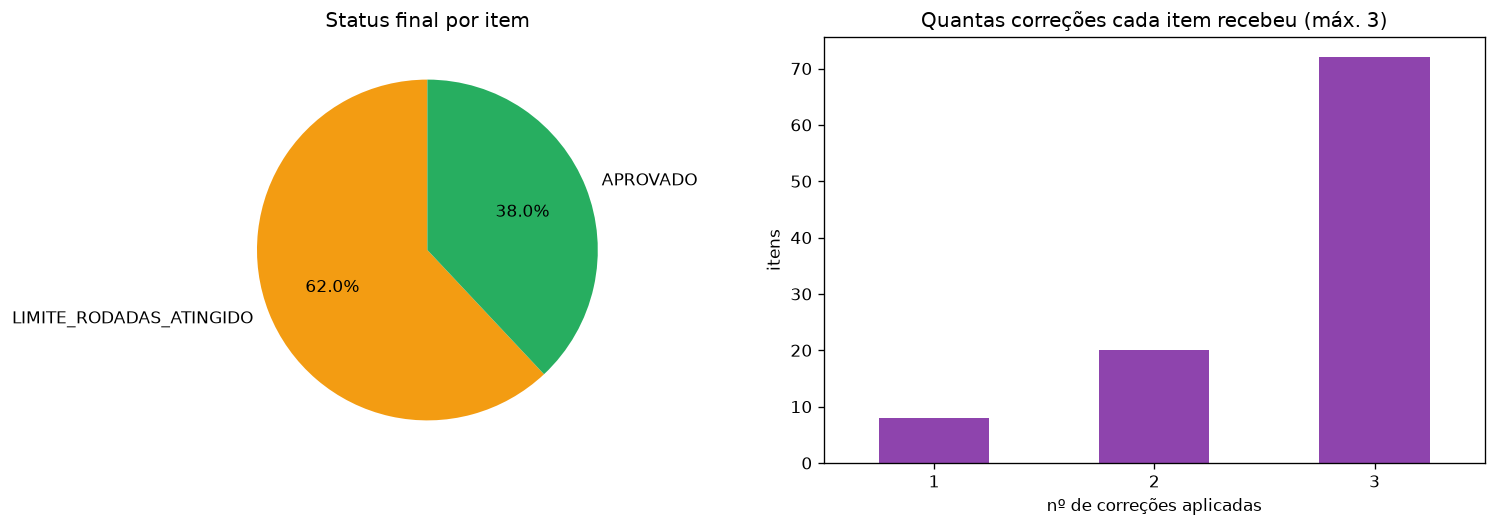

status_final
LIMITE_RODADAS_ATINGIDO    62
APROVADO                   38

Média de problemas de código por item - antes: 2.61 | depois: 0.86
Itens que zeraram problemas de código: 43 / 100


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

cont_status = resumo['status_final'].value_counts()
axes[0].pie(cont_status.values, labels=cont_status.index,
            colors=[CORES_STATUS.get(s, '#888') for s in cont_status.index],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Status final por item')

resumo['n_correcoes'].value_counts().sort_index().plot(kind='bar', color='#8e44ad', ax=axes[1])
axes[1].set_xlabel('nº de correções aplicadas'); axes[1].set_ylabel('itens')
axes[1].set_title('Quantas correções cada item recebeu (máx. 3)')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

media_inicial = resumo['n_melhorias_inicial'].mean()
media_final = resumo['n_melhorias_final'].mean()
print(cont_status.to_string())
print(f'\nMédia de problemas de código por item - antes: {media_inicial:.2f} | depois: {media_final:.2f}')
print(f'Itens que zeraram problemas de código: {(resumo["n_melhorias_final"] == 0).sum()} / {len(resumo)}')


### 6.3 Persistência dos critérios após as tentativas de correção

**Objetivo.** Verificar se o critério visado por uma alteração declarada continua ativo
na avaliação seguinte. A classificação operacional é:

- `RESOLVIDO`: o critério não foi detectado na rodada seguinte;
- `NAO_RESOLVIDO`: o critério voltou a ser detectado;
- `NAO_VERIFICADO`: não existe avaliação posterior disponível.

Esses nomes são mantidos nos arquivos por compatibilidade, mas o resultado deve ser lido
como **recorrência ou não recorrência do critério**, e não como comprovação causal.

In [59]:
registros_efetividade = []
for qid, rodadas in historicos.items():
    for i, rodada in enumerate(rodadas):
        alteracoes = (rodada.get('correcao') or {}).get('alteracoes') or []
        if not alteracoes:
            continue
        proxima = rodadas[i + 1] if i + 1 < len(rodadas) else None
        criterios_proxima = set(proxima.get('criterios_ativos', [])) if proxima else None
        for alt in alteracoes:
            crit = alt.get('criterio_numero')
            if criterios_proxima is None:
                status_efetividade = 'NAO_VERIFICADO'
            elif crit in criterios_proxima:
                status_efetividade = 'NAO_RESOLVIDO'
            else:
                status_efetividade = 'RESOLVIDO'
            registros_efetividade.append({
                'question_id': qid, 'rodada': rodada['rodada'], 'criterio_numero': crit,
                'criterio_nome': alt.get('criterio_nome'), 'eixo': alt.get('eixo'),
                'acao_realizada': alt.get('acao_realizada'), 'status_efetividade': status_efetividade,
            })

df_efetividade = pd.DataFrame(registros_efetividade)
df_efetividade.to_csv(PASTA_CORRECAO / 'relatorio_efetividade_correcoes.csv', index=False, encoding='utf-8-sig')

print(f'{len(df_efetividade)} alterações avaliadas por critério | salvo em relatorio_efetividade_correcoes.csv\n')
print(df_efetividade['status_efetividade'].value_counts().to_string())


563 alterações avaliadas por critério | salvo em relatorio_efetividade_correcoes.csv

status_efetividade
RESOLVIDO        317
NAO_RESOLVIDO    246


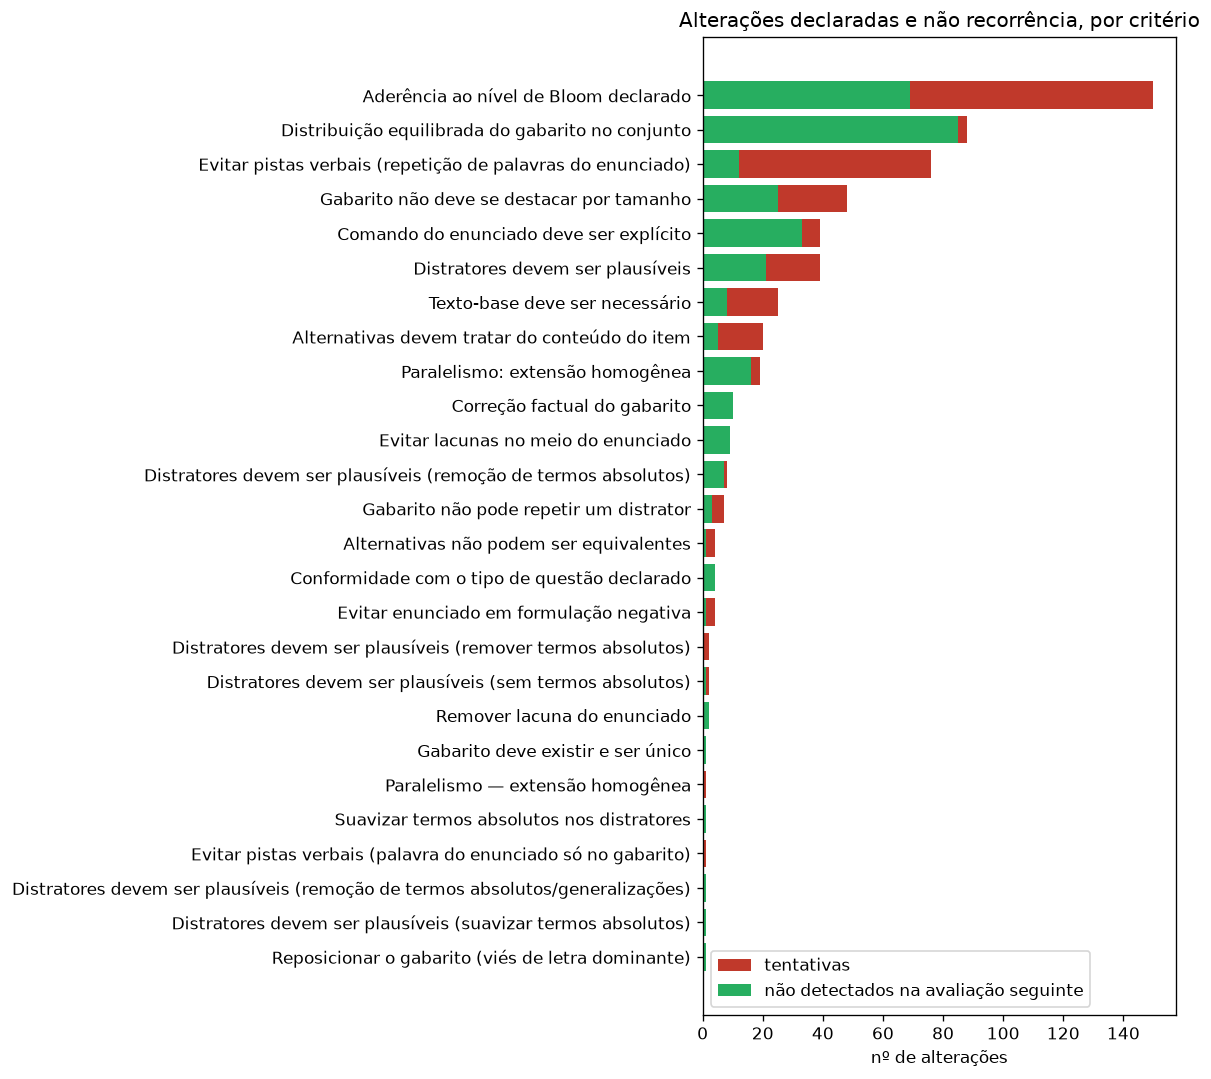

,criterio_numero,criterio_nome,tentativas,resolvidos,taxa_sucesso_%
22,17,Aderência ao nível de Bloom declarado,150,69,46.0
24,19,Distribuição equilibrada do gabarito no conjunto,88,85,96.6
15,9,Evitar pistas verbais (repetição de palavras do enunciado),76,12,15.8
6,6,Gabarito não deve se destacar por tamanho,48,25,52.1
17,11,Comando do enunciado deve ser explícito,39,33,84.6
7,7,Distratores devem ser plausíveis,39,21,53.8
20,15,Texto-base deve ser necessário,25,8,32.0
21,16,Alternativas devem tratar do conteúdo do item,20,5,25.0
5,5,Paralelismo: extensão homogênea,19,16,84.2
3,4,Correção factual do gabarito,10,10,100.0


In [60]:
por_criterio = df_efetividade.groupby(['criterio_numero', 'criterio_nome'])['status_efetividade'].agg(
    tentativas='count',
    resolvidos=lambda s: (s == 'RESOLVIDO').sum(),
).reset_index()
por_criterio['taxa_sucesso_%'] = (por_criterio['resolvidos'] / por_criterio['tentativas'] * 100).round(1)
por_criterio = por_criterio.sort_values('tentativas', ascending=False)
por_criterio.to_csv(PASTA_CORRECAO / 'relatorio_por_criterio.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(10, max(3, len(por_criterio) * 0.35)))
ax.barh(por_criterio['criterio_nome'], por_criterio['tentativas'], color='#c0392b', label='tentativas')
ax.barh(por_criterio['criterio_nome'], por_criterio['resolvidos'], color='#27ae60', label='não detectados na avaliação seguinte')
ax.set_xlabel('nº de alterações'); ax.set_title('Alterações declaradas e não recorrência, por critério')
ax.legend(); ax.invert_yaxis()
plt.tight_layout(); plt.show()

por_criterio


### 6.4 Critérios novos detectados após as correções

**Objetivo.** Identificar critérios ausentes antes de uma correção e presentes na
avaliação seguinte. Esses casos são registrados como `regressoes` nos arquivos do projeto,
mas a interpretação adequada é **possível regressão**: a nova ocorrência pode representar
um efeito indesejado da mudança ou uma variação da avaliação, especialmente nos critérios
que dependem da LLM.

139 regressões detectadas em 100 itens (41 itens afetados)



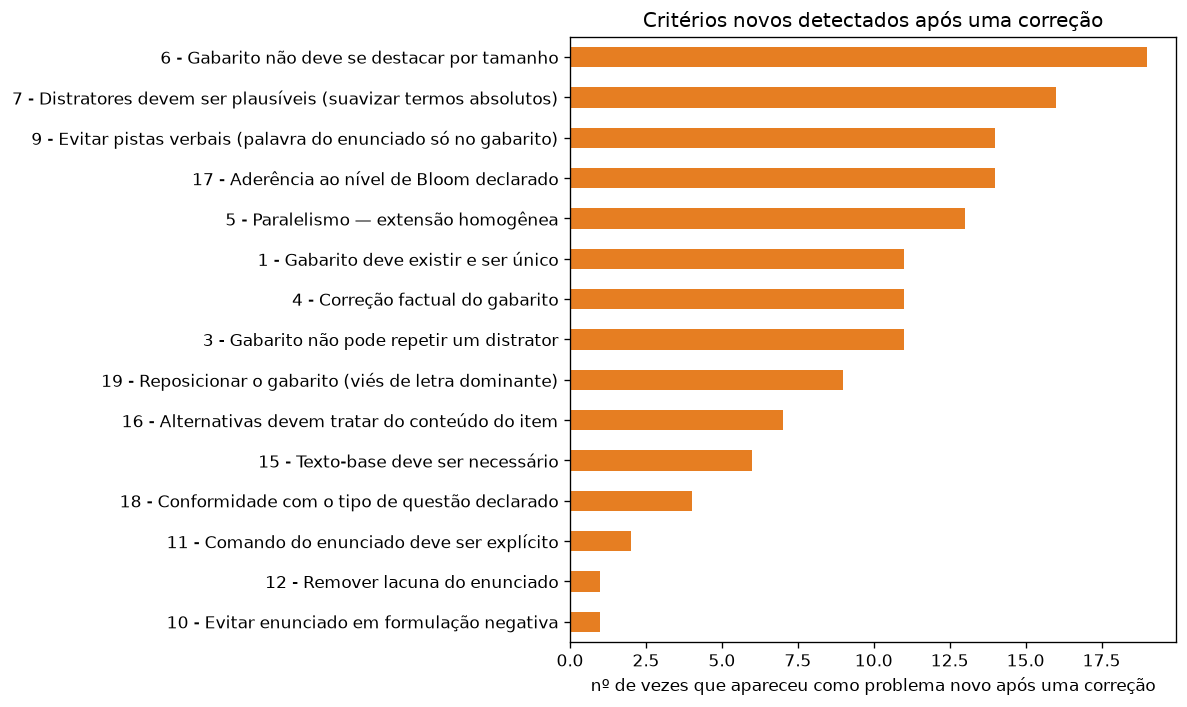

6 - Gabarito não deve se destacar por tamanho                       19
7 - Distratores devem ser plausíveis (suavizar termos absolutos)    16
17 - Aderência ao nível de Bloom declarado                          14
9 - Evitar pistas verbais (palavra do enunciado só no gabarito)     14
5 - Paralelismo — extensão homogênea                                13
1 - Gabarito deve existir e ser único                               11
3 - Gabarito não pode repetir um distrator                          11
4 - Correção factual do gabarito                                    11
19 - Reposicionar o gabarito (viés de letra dominante)               9
16 - Alternativas devem tratar do conteúdo do item                   7
15 - Texto-base deve ser necessário                                  6
18 - Conformidade com o tipo de questão declarado                    4
11 - Comando do enunciado deve ser explícito                         2
10 - Evitar enunciado em formulação negativa                         1
12 - R

In [61]:
regressoes = []
for qid, rodadas in historicos.items():
    for i in range(len(rodadas) - 1):
        atual, proxima = rodadas[i], rodadas[i + 1]
        if atual.get('status') != 'CORRIGIDO':
            continue
        criterios_antes = set(atual.get('criterios_ativos', []))
        criterios_depois = set(proxima.get('criterios_ativos', []))
        criterios_visados = {alt.get('criterio_numero') for alt in (atual.get('correcao') or {}).get('alteracoes', [])}
        novos = criterios_depois - criterios_antes
        for crit in novos:
            regressoes.append({
                'question_id': qid,
                'rodada_da_correcao': atual['rodada'],
                'criterios_visados_pela_correcao': sorted(criterios_visados),
                'criterio_novo_introduzido': crit,
            })

df_regressoes = pd.DataFrame(regressoes)
df_regressoes.to_csv(PASTA_CORRECAO / 'relatorio_regressoes.csv', index=False, encoding='utf-8-sig')

print(f'{len(df_regressoes)} regressões detectadas em {len(historicos)} itens '
      f'({df_regressoes["question_id"].nunique() if len(df_regressoes) else 0} itens afetados)\n')

if len(df_regressoes):
    NOME_CRITERIO = dict(zip(por_criterio['criterio_numero'], por_criterio['criterio_nome']))
    contagem_regressoes = df_regressoes['criterio_novo_introduzido'].value_counts()
    contagem_regressoes.index = [f"{n} - {NOME_CRITERIO.get(n, '?')}" for n in contagem_regressoes.index]
    fig, ax = plt.subplots(figsize=(10, max(3, len(contagem_regressoes) * 0.4)))
    contagem_regressoes.sort_values().plot(kind='barh', color='#e67e22', ax=ax)
    ax.set_xlabel('nº de vezes que apareceu como problema novo após uma correção')
    ax.set_title('Critérios novos detectados após uma correção')
    plt.tight_layout(); plt.show()
    print(contagem_regressoes.to_string())
else:
    print('Nenhum critério novo foi detectado após as correções avaliadas.')


### 6.5 Itens com maior e menor remoção dos critérios iniciais

**Objetivo.** Ordenar os itens pela fração de critérios iniciais que não aparecem na
última rodada. Uma taxa igual a 1,0 significa que todos os critérios **iniciais**
desapareceram; não significa necessariamente aprovação, pois um critério novo pode ter
surgido. Por isso, o ranking exibe também `status_final` e `criterios_finais`.

=== Dez itens com maior remoção dos critérios iniciais ===
 question_id            question_type            status_final      criterios_iniciais criterios_finais  taxa_resolucao
         792     Afirmação Incompleta                APROVADO [7, 12, 15, 16, 17, 19]               []             1.0
          39 Múltipla Escolha Simples                APROVADO      [6, 7, 11, 17, 19]               []             1.0
         252     Afirmação Incompleta LIMITE_RODADAS_ATINGIDO      [5, 6, 12, 17, 19]              [7]             1.0
         794     Afirmação Incompleta                APROVADO      [6, 7, 15, 17, 19]               []             1.0
         184 Múltipla Escolha Simples                APROVADO         [9, 11, 17, 19]               []             1.0
         227     Afirmação Incompleta                APROVADO         [7, 12, 17, 19]               []             1.0
         251     Afirmação Incompleta LIMITE_RODADAS_ATINGIDO        [12, 15, 17, 19]     [5, 6, 7, 9]      

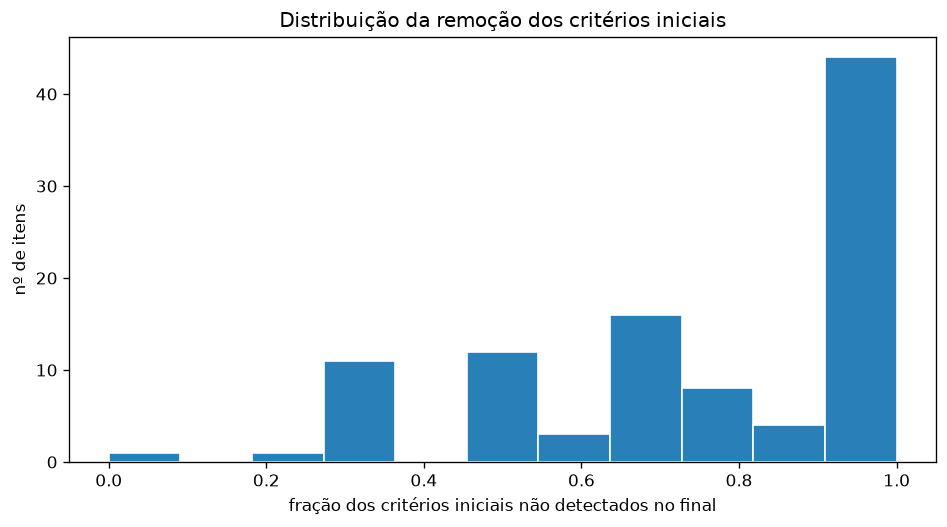

In [62]:
com_taxa = resumo[resumo['taxa_resolucao'].notna()].copy()

print('=== Dez itens com maior remoção dos critérios iniciais ===')
melhores = com_taxa.sort_values(['taxa_resolucao', 'n_criterios_resolvidos'], ascending=False).head(10)
display_cols = ['question_id', 'question_type', 'status_final', 'criterios_iniciais',
                'criterios_finais', 'taxa_resolucao']
print(melhores[display_cols].to_string(index=False))

print('\n=== Dez itens com menor remoção dos critérios iniciais ===')
piores = com_taxa.sort_values(['taxa_resolucao', 'n_criterios_resolvidos'], ascending=True).head(10)
print(piores[display_cols].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(com_taxa['taxa_resolucao'], bins=11, range=(0, 1), color='#2980b9', edgecolor='white')
ax.set_xlabel('fração dos critérios iniciais não detectados no final')
ax.set_ylabel('nº de itens')
ax.set_title('Distribuição da remoção dos critérios iniciais')
plt.tight_layout(); plt.show()


### 6.6 Resultado por tipo de questão

**Objetivo.** Comparar aprovação, remoção de critérios e número de correções entre os
formatos. O número de itens (`n_itens`) deve ser considerado antes de comparar percentuais:
grupos pequenos podem apresentar taxas muito altas ou baixas por causa de poucos casos.
Esta tabela é descritiva e não testa se as diferenças entre tipos são estatisticamente
significativas.

In [63]:
por_tipo = resumo.groupby('question_type').agg(
    n_itens=('question_id', 'count'),
    aprovados=('status_final', lambda s: (s == 'APROVADO').sum()),
    taxa_resolucao_media=('taxa_resolucao', 'mean'),
    correcoes_media=('n_correcoes', 'mean'),
).round(2)
por_tipo['taxa_aprovacao_%'] = (por_tipo['aprovados'] / por_tipo['n_itens'] * 100).round(1)
por_tipo = por_tipo.sort_values('n_itens', ascending=False)
por_tipo.to_csv(PASTA_CORRECAO / 'relatorio_por_tipo.csv', encoding='utf-8-sig')
por_tipo


,n_itens,aprovados,taxa_resolucao_media,correcoes_media,taxa_aprovacao_%
question_type,,,,,
Múltipla Escolha Simples,51,20,0.73,2.63,39.2
Afirmação Incompleta,45,18,0.80,2.62,40.0
Asserção-Razão,2,0,0.71,3.00,0.0
Múltipla Escolha Complexa,2,0,0.90,3.00,0.0


### 6.7 Critérios que mais impedem a aprovação: código determinístico vs. avaliação LLM

**Objetivo.** Nos itens que não chegaram a `APROVADO`, verificar quais dos 19 critérios do
catálogo permanecem ativos com mais frequência na última rodada da correção, e se essa
persistência vem da checagem determinística de código, da avaliação pedagógica (LLM), ou
de ambas concordando. Um critério dominado por "só código" é candidato a falso positivo:
a checagem é lexical (sobreposição de palavras, verbos-gatilho de Bloom) e pode não
captar paráfrase ou sinônimo que uma leitura completa (LLM) já validou como adequada.

Esta análise usa `data/sabia-4-thinking/loop_correcao_v2`, a corrida mais recente do loop
de correção.

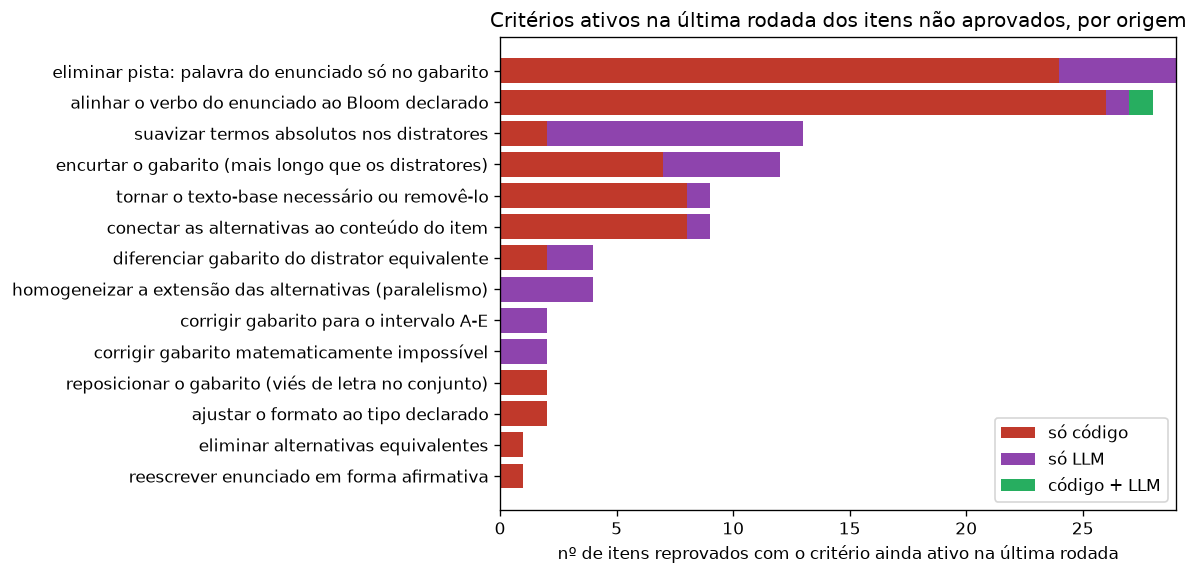

61 itens não aprovados analisados em data/sabia-4-thinking/loop_correcao_v2



origem,criterio,nome,so_codigo,so_llm,ambos,ocorrencias
0,9,eliminar pista: palavra do enunciado só no gabarito,24,5,0,29
1,17,alinhar o verbo do enunciado ao Bloom declarado,26,1,1,28
2,7,suavizar termos absolutos nos distratores,2,11,0,13
3,6,encurtar o gabarito (mais longo que os distratores),7,5,0,12
4,15,tornar o texto-base necessário ou removê-lo,8,1,0,9
5,16,conectar as alternativas ao conteúdo do item,8,1,0,9
6,3,diferenciar gabarito do distrator equivalente,2,2,0,4
7,5,homogeneizar a extensão das alternativas (paralelismo),0,4,0,4
8,1,corrigir gabarito para o intervalo A-E,0,2,0,2
9,4,corrigir gabarito matematicamente impossível,0,2,0,2


In [64]:
from collections import defaultdict

PASTA_ANALISE_CRITERIOS = Path('data/sabia-4-thinking/loop_correcao_v2')
letra_dom_criterios = corr.calcular_letra_dominante()

crit_nome = {}
for flag, num in diag.FLAG_PARA_CRITERIO.items():
    crit_nome.setdefault(num, diag.MELHORIAS.get(flag, (flag, ''))[0])

registros_bloqueio = []
arquivos_criterios = sorted(PASTA_ANALISE_CRITERIOS.glob('*.json'),
                             key=lambda p: int(p.stem) if p.stem.isdigit() else -1)
for caminho in arquivos_criterios:
    if not caminho.stem.isdigit():
        continue
    rodadas = json.loads(caminho.read_text(encoding='utf-8'))
    if not rodadas or rodadas[-1]['status'] == 'APROVADO':
        continue
    ultima = rodadas[-1]
    item_final = ultima.get('item', {})
    avaliacao_llm_final = ultima.get('avaliacao_llm')

    flags = dict(diag.aplicar_formulacao_estrutura(item_final, usar_verificacao_matematica_conhecida=False))
    bloom_flag, _ = diag.bloom_desalinhado(item_final)
    flags['ap_bloom_desalinhado'] = bloom_flag
    erros_formato = diag.diagnosticar_formato(item_final)
    flags['ap_formato_incompativel'] = len(erros_formato) > 0
    gabarito_atual = str(item_final.get('correct_option', '')).strip().upper()
    flags['apl_gabarito_letra_dominante'] = (
        bool(letra_dom_criterios) and gabarito_atual == str(letra_dom_criterios).upper())

    cod = set(diag.criterios_flagrados_por_codigo(flags))
    llm_flag = set(diag.criterios_flagrados_por_llm(avaliacao_llm_final))
    ativos = set(ultima.get('criterios_ativos') or [])

    for c in ativos:
        if c in cod and c in llm_flag:
            origem = 'ambos'
        elif c in cod:
            origem = 'so_codigo'
        elif c in llm_flag:
            origem = 'so_llm'
        else:
            origem = 'indefinido'
        registros_bloqueio.append({
            'question_id': int(caminho.stem), 'criterio': c,
            'nome': crit_nome.get(c, '?'), 'origem': origem,
        })

df_bloqueio = pd.DataFrame(registros_bloqueio)
n_reprovados_criterios = df_bloqueio['question_id'].nunique()

ranking_criterios = (
    df_bloqueio.groupby(['criterio', 'nome'])['origem']
    .value_counts().unstack(fill_value=0)
    .reindex(columns=['so_codigo', 'so_llm', 'ambos'], fill_value=0)
)
ranking_criterios['ocorrencias'] = ranking_criterios.sum(axis=1)
ranking_criterios = ranking_criterios.sort_values('ocorrencias', ascending=False).reset_index()
ranking_criterios.to_csv(PASTA_ANALISE_CRITERIOS / 'relatorio_criterios_bloqueio_final.csv',
                          index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(10, max(3, len(ranking_criterios) * 0.35)))
ax.barh(ranking_criterios['nome'], ranking_criterios['so_codigo'], color='#c0392b', label='só código')
ax.barh(ranking_criterios['nome'], ranking_criterios['so_llm'],
        left=ranking_criterios['so_codigo'], color='#8e44ad', label='só LLM')
ax.barh(ranking_criterios['nome'], ranking_criterios['ambos'],
        left=ranking_criterios['so_codigo'] + ranking_criterios['so_llm'], color='#27ae60', label='código + LLM')
ax.set_xlabel('nº de itens reprovados com o critério ainda ativo na última rodada')
ax.set_title('Critérios ativos na última rodada dos itens não aprovados, por origem')
ax.legend(); ax.invert_yaxis()
plt.tight_layout(); plt.show()

print(f'{n_reprovados_criterios} itens não aprovados analisados em {PASTA_ANALISE_CRITERIOS}\n')
ranking_criterios

In [65]:
itens_reprovados_totais = set(df_bloqueio['question_id'])
itens_com_llm_real = set(df_bloqueio.loc[df_bloqueio['origem'].isin(['so_llm', 'ambos']), 'question_id'])
travados_so_codigo = itens_reprovados_totais - itens_com_llm_real

print(f'Itens reprovados travados 100% por critérios que a LLM não flagra (só código insiste): '
      f'{len(travados_so_codigo)} de {n_reprovados_criterios}')
print(f'Itens reprovados com pelo menos 1 critério também confirmado pela LLM: {len(itens_com_llm_real)}')

Itens reprovados travados 100% por critérios que a LLM não flagra (só código insiste): 47 de 61
Itens reprovados com pelo menos 1 critério também confirmado pela LLM: 14


**Achado.** Dos 100 itens selecionados, 38 foram aprovados. Dos 62 que não chegaram a
`APROVADO`, 61 ainda tinham ao menos um critério ativo na última rodada - e desses,
**47 (77%) ficam travados inteiramente por critérios que só o código ainda flagra: a
avaliação LLM concorda que o item está bem em tudo o que resta.** Ou seja, três em cada
quatro reprovações não decorrem de um problema que a leitura completa (LLM) ainda
reconhece como real, e sim de checagens lexicais determinísticas (sobretudo os critérios
9, 16 e 17) que continuam acionando sobre o mesmo padrão de texto mesmo depois de o
corretor e a avaliação LLM validarem o conteúdo. O item restante (`question_id` 117)
chegou ao limite de rodadas sem nenhum critério ativo - nesse caso o impedimento veio da
decisão geral da LLM (`sintese.decisao_recomendada`), não de um critério específico.

### 6.8 Comparação item a item entre modelos e versões do loop de correção

**Objetivo.** Verificar se a melhora na taxa de aprovação entre corridas é consistente
item a item, ou se a aprovação migra de item para item conforme o modelo/versão usado no
loop de correção. As três pastas comparadas processaram os mesmos 100 itens selecionados,
mas **não são apenas reexecuções da mesma configuração**: `sabia-4/loop_correcao_v1` e
`sabia-4/loop_correcao_v2` usam o modelo `sabia-4`, enquanto `sabia-4-thinking/loop_correcao_v2`
usa a variante com raciocínio estendido - a comparação mistura efeito de versão do prompt
com efeito de modelo.

In [66]:
def status_final_por_item(pasta) -> dict:
    situacao = {}
    for caminho in Path(pasta).glob('*.json'):
        if not caminho.stem.isdigit():
            continue
        rodadas = json.loads(caminho.read_text(encoding='utf-8'))
        situacao[int(caminho.stem)] = rodadas[-1]['status'] if rodadas else None
    return situacao

status_sabia4_v1 = status_final_por_item('data/sabia-4/loop_correcao_v1')
status_sabia4_v2 = status_final_por_item('data/sabia-4/loop_correcao_v2')
status_sabia4think_v2 = status_final_por_item('data/sabia-4-thinking/loop_correcao_v2')

ids_comuns = sorted(set(status_sabia4_v1) & set(status_sabia4_v2) & set(status_sabia4think_v2))

comparacao_versoes = pd.DataFrame({
    'sabia4_v1': pd.Series(status_sabia4_v1),
    'sabia4_v2': pd.Series(status_sabia4_v2),
    'sabia4think_v2': pd.Series(status_sabia4think_v2),
}).loc[ids_comuns]

colunas_aprovado = []
for coluna in ['sabia4_v1', 'sabia4_v2', 'sabia4think_v2']:
    nome_aprov = f'aprovado_{coluna}'
    comparacao_versoes[nome_aprov] = comparacao_versoes[coluna] == 'APROVADO'
    colunas_aprovado.append(nome_aprov)

print(f'{len(ids_comuns)} itens em comum nas 3 pastas')
print('Total de aprovados por pasta:')
print(comparacao_versoes[colunas_aprovado].sum().to_string())
print()

cruzamento_aprovacao = (
    comparacao_versoes.groupby(colunas_aprovado).size().rename('n_itens').reset_index()
    .sort_values('n_itens', ascending=False)
)
cruzamento_aprovacao

100 itens em comum nas 3 pastas
Total de aprovados por pasta:
aprovado_sabia4_v1         16
aprovado_sabia4_v2         43
aprovado_sabia4think_v2    38



,aprovado_sabia4_v1,aprovado_sabia4_v2,aprovado_sabia4think_v2,n_itens
0,False,False,False,42
3,False,True,True,21
2,False,True,False,13
1,False,False,True,8
7,True,True,True,7
4,True,False,False,5
5,True,False,True,2
6,True,True,False,2


In [67]:
sempre_aprovado = comparacao_versoes[comparacao_versoes[colunas_aprovado].all(axis=1)]
nunca_aprovado = comparacao_versoes[~comparacao_versoes[colunas_aprovado].any(axis=1)]
regrediu = comparacao_versoes[
    (comparacao_versoes['aprovado_sabia4_v1'] | comparacao_versoes['aprovado_sabia4_v2'])
    & ~comparacao_versoes['aprovado_sabia4think_v2']
]

print(f'Aprovado nas 3 pastas: {len(sempre_aprovado)} -> {sorted(sempre_aprovado.index)}')
print(f'Reprovado nas 3 pastas: {len(nunca_aprovado)}')
print(f'Aprovado em sabia4_v1 ou sabia4_v2, mas não em sabia4think_v2 (regressão): '
      f'{len(regrediu)} -> {sorted(regrediu.index)}')
regrediu[['sabia4_v1', 'sabia4_v2', 'sabia4think_v2']]

Aprovado nas 3 pastas: 7 -> [32, 69, 224, 227, 356, 567, 767]
Reprovado nas 3 pastas: 42
Aprovado em sabia4_v1 ou sabia4_v2, mas não em sabia4think_v2 (regressão): 20 -> [22, 26, 86, 93, 122, 132, 167, 251, 252, 322, 334, 360, 364, 457, 536, 645, 700, 707, 753, 844]


,sabia4_v1,sabia4_v2,sabia4think_v2
22,LIMITE_RODADAS_ATINGIDO,APROVADO,LIMITE_RODADAS_ATINGIDO
26,LIMITE_RODADAS_ATINGIDO,APROVADO,LIMITE_RODADAS_ATINGIDO
86,APROVADO,APROVADO,LIMITE_RODADAS_ATINGIDO
93,APROVADO,APROVADO,LIMITE_RODADAS_ATINGIDO
122,LIMITE_RODADAS_ATINGIDO,APROVADO,LIMITE_RODADAS_ATINGIDO
132,APROVADO,LIMITE_RODADAS_ATINGIDO,LIMITE_RODADAS_ATINGIDO
167,LIMITE_RODADAS_ATINGIDO,APROVADO,LIMITE_RODADAS_ATINGIDO
251,LIMITE_RODADAS_ATINGIDO,APROVADO,LIMITE_RODADAS_ATINGIDO
252,LIMITE_RODADAS_ATINGIDO,APROVADO,LIMITE_RODADAS_ATINGIDO
322,APROVADO,LIMITE_RODADAS_ATINGIDO,LIMITE_RODADAS_ATINGIDO


**Achado.** Dos 100 itens em comum às três pastas, `sabia-4/v1` aprovou 16, `sabia-4/v2`
aprovou 43 e `sabia-4-thinking/v2` aprovou 38. Apenas **7 itens são aprovados nas três**
(32, 69, 224, 227, 356, 567, 767) - um núcleo pequeno e consistente de itens sem problema
em nenhuma combinação de modelo/versão. No outro extremo, **42 itens nunca são aprovados**
em nenhuma das três, o que é um indício mais forte de problema real e persistente nesses
casos específicos.

O ponto mais relevante para interpretar a evolução entre corridas: **20 itens
regrediram** - foram aprovados em pelo menos uma corrida anterior (`sabia-4/v1` ou
`sabia-4/v2`) mas não na mais recente (`sabia-4-thinking/v2`). Isso mostra que a melhora
na taxa de aprovação agregada entre corridas não é estritamente incremental por item: o
modelo/versão mais recente aprova mais itens no total, mas não é estritamente melhor
para cada item considerado individualmente.

<a id="parte7"></a>
## Parte 7 - Síntese final

A síntese reúne os principais números produzidos nas etapas anteriores. Ela deve ser lida
como um resumo do comportamento do pipeline nesta base, e não como validação definitiva
da qualidade dos itens.

### Como interpretar os status finais

- `APROVADO`: nenhum critério permaneceu ativo e a avaliação realizada pela LLM recomendou aprovação;
- `LIMITE_RODADAS_ATINGIDO`: ainda havia critério ativo após a terceira correção;
- `DESCARTADO`: foi detectada uma condição definida como inviável para correção automática;
- `ERRO_CORRECAO`: o ciclo terminou por falha na geração ou validação da correção.

Ao comunicar os resultados, recomenda-se apresentar em conjunto: status final, redução de
problemas identificados pelas verificações automatizadas, recorrência dos critérios visados
e critérios novos detectados. Nenhum
desses indicadores, isoladamente, descreve todo o resultado da correção.

### Limitações que acompanham a conclusão

1. Os resultados produzidos pela LLM podem variar entre execuções.
2. As verificações automatizadas são aproximações operacionais dos critérios de qualidade.
3. A ausência de um critério na rodada seguinte não demonstra, sozinha, causalidade.
4. Comparações por tipo de questão são descritivas e dependem do tamanho de cada grupo.

A célula final imprime um quadro compacto para conferência e registro da execução.

In [68]:
print('=' * 66)
print('SÍNTESE - PROCESSO COMPLETO (WAPLA 2026)')
print('=' * 66)
print(f'Itens rejeitados analisados (Parte 1-2): {len(df)}')
print(f'Itens selecionados para refino (Parte 3): {len(selecionados_novos)}')
print(f'Itens com correção executada e analisada (Parte 6): {len(resumo)}')
print()
print('DIAGNÓSTICO (239 itens)')
for cat, n in df_diagnosticado['categoria'].value_counts().items():
    print(f'  {cat:<22} {n:>4} ({n/len(df_diagnosticado)*100:5.1f}%)')
print()
print('CORREÇÃO (itens selecionados)')
for status, n in resumo['status_final'].value_counts().items():
    print(f'  {status:<28} {n:>4} ({n/len(resumo)*100:5.1f}%)')
print()
print(f'Problemas de código por item - antes: {media_inicial:.2f} | depois: {media_final:.2f} '
      f'({(1 - media_final/media_inicial)*100 if media_inicial else 0:.1f}% de redução)')
if len(df_efetividade):
    taxa_geral = (df_efetividade['status_efetividade'] == 'RESOLVIDO').mean() * 100
    print(f'Alterações avaliadas por critério: {len(df_efetividade)} | '
          f'não recorrência na avaliação seguinte: {taxa_geral:.1f}%')
print(f'Possíveis regressões (critérios novos detectados após correção): {len(df_regressoes)}')
print()
print('POR TIPO DE QUESTÃO')
print(por_tipo[['n_itens', 'aprovados', 'taxa_aprovacao_%', 'taxa_resolucao_media']].to_string())
print('=' * 66)


SÍNTESE - PROCESSO COMPLETO (WAPLA 2026)
Itens rejeitados analisados (Parte 1-2): 239
Itens selecionados para refino (Parte 3): 100
Itens com correção executada e analisada (Parte 6): 100

DIAGNÓSTICO (239 itens)
  REFINAR_SELECIONADO     100 ( 41.8%)
  REFINAR                  75 ( 31.4%)
  INVESTIGAR               63 ( 26.4%)
  DESCARTAR                 1 (  0.4%)

CORREÇÃO (itens selecionados)
  LIMITE_RODADAS_ATINGIDO        62 ( 62.0%)
  APROVADO                       38 ( 38.0%)

Problemas de código por item - antes: 2.61 | depois: 0.86 (67.0% de redução)
Alterações avaliadas por critério: 563 | não recorrência na avaliação seguinte: 56.3%
Possíveis regressões (critérios novos detectados após correção): 139

POR TIPO DE QUESTÃO
                           n_itens  aprovados  taxa_aprovacao_%  taxa_resolucao_media
question_type                                                                        
Múltipla Escolha Simples        51         20              39.2                  0.7

### Leitura complementar da síntese: ajuste pelos achados das seções 6.7 e 6.8

A seção 6.7 mostrou que, dos 62 itens que não chegaram a `APROVADO`, **47 (77% dos 61 com
critério ainda ativo) ficam travados inteiramente por critérios que só a checagem de
código ainda aciona - a avaliação LLM concorda que o item está adequado em tudo o que
resta.** Nesses 47 casos, a reprovação reflete um limite da heurística lexical
determinística (concentrada nos critérios 9, 16 e 17), não um problema de conteúdo ainda
não resolvido segundo a leitura completa do item. Para uma leitura alternativa do
resultado, esses itens podem ser tratados como efetivamente aprovados.

**Ressalva.** Essa reclassificação cobre só os critérios estruturais (FE/AP/APL) que têm
checagem equivalente em código e em LLM (`CRITERIO_PARA_CAMPOS_LLM`). Ela não reflete
aspectos subjetivos da avaliação sem checagem de código correspondente (por exemplo
`opiniao_subjetividade`, `adequacao_nivel_ensino`) - por isso deve ser lida como uma
análise de sensibilidade sobre o resultado, e não como substituição do `status_final`
oficial usado no restante deste notebook.

A seção 6.8 acrescenta outra ressalva à leitura da evolução entre corridas: a melhora na
taxa de aprovação agregada (`sabia-4/v1` → `sabia-4/v2` → `sabia-4-thinking/v2`) não é
estritamente incremental por item - 20 itens aprovados numa corrida anterior regrediram
na mais recente, e apenas 7 itens são aprovados de forma consistente nas três.

In [ ]:
resumo['aprovado_ajustado'] = (
    resumo['status_final'].eq('APROVADO') | resumo['question_id'].isin(travados_so_codigo)
)

n_aprovado_original = int(resumo['status_final'].eq('APROVADO').sum())
n_aprovado_ajustado = int(resumo['aprovado_ajustado'].sum())

print('SÍNTESE AJUSTADA - itens travados só por checagem de código considerados aprovados')
print('=' * 66)
print(f'Aprovado (status_final oficial):             {n_aprovado_original:>3} de {len(resumo)} '
      f'({n_aprovado_original / len(resumo) * 100:5.1f}%)')
print(f'+ travados só por checagem de código (6.7):  {len(travados_so_codigo):>3}')
print(f'Aprovado (leitura ajustada):                  {n_aprovado_ajustado:>3} de {len(resumo)} '
      f'({n_aprovado_ajustado / len(resumo) * 100:5.1f}%)')
print()
print('Por tipo de questão (leitura ajustada):')
print(resumo.groupby('question_type')['aprovado_ajustado']
      .agg(aprovados_ajustado='sum', n_itens='count').to_string())
print()
print('Consistência entre corridas (seção 6.8, sobre os 100 itens em comum):')
print(f'  Aprovado nas 3 pastas (sabia-4/v1, sabia-4/v2, sabia-4-thinking/v2): {len(sempre_aprovado)}')
print(f'  Nunca aprovado nas 3 pastas:                                        {len(nunca_aprovado)}')
print(f'  Regrediu (aprovado antes, não na corrida mais recente):             {len(regrediu)}')